# Coupled 2D-3D flow-particle analysis



In [14]:
# ============================================================
# 1. IMPORTS AND PROJECT PATHS
# ============================================================

from pathlib import Path
import sys
import shutil
import importlib
import warnings
import json

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.lines import Line2D
from IPython.display import display


NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent

PARCELS_DIR = PROJECT_DIR / "z.parcels_postprocessing"
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"

for path in [PROJECT_DIR, FLOW_DIR, PARCELS_DIR, FLOW_SCRIPTS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)


import scripts.fieldset as pfs
import scripts.run as prun
import scripts.metrics_clustering as mclus
import scripts.notebook_helpers as phelp
import theme.plot_theme as ptheme
import shcherbina_utils as shu

for module in [pfs, prun, mclus, phelp, ptheme, shu]:
    importlib.reload(module)

ptheme.apply_theme()
shu.apply_plot_style()


def apply_comparison_style():
    """Use the same A4-readable sizing as compare_2D_3D_flow.ipynb."""
    font_size = max(getattr(ptheme, "FONT_SIZE", 14), 20)
    title_size = max(getattr(ptheme, "TITLE_SIZE", font_size + 2), 26)
    label_size = max(getattr(ptheme, "LABEL_SIZE", font_size), 24)
    tick_size = max(getattr(ptheme, "TICK_SIZE", font_size - 2), 21)
    legend_size = max(getattr(ptheme, "LEGEND_SIZE", font_size - 6), 14)
    annotation_size = max(getattr(ptheme, "ANNOTATION_SIZE", font_size - 2), 19)
    suptitle_size = max(getattr(ptheme, "SUPTITLE_SIZE", title_size + 2), 30)

    plt.rcParams.update({
        "font.size": font_size,
        "axes.titlesize": title_size,
        "axes.labelsize": label_size,
        "xtick.labelsize": tick_size,
        "ytick.labelsize": tick_size,
        "legend.fontsize": legend_size,
        "figure.titlesize": suptitle_size,
    })

    return {
        "font": font_size,
        "title": title_size,
        "label": label_size,
        "tick": tick_size,
        "legend": legend_size,
        "annotation": annotation_size,
        "suptitle": suptitle_size,
    }


PLOT_SIZES = apply_comparison_style()


def enforce_axis_text_sizes(ax):
    ax.title.set_fontsize(PLOT_SIZES["title"])
    ax.xaxis.label.set_fontsize(PLOT_SIZES["label"])
    ax.yaxis.label.set_fontsize(PLOT_SIZES["label"])
    ax.tick_params(axis="both", which="major", labelsize=PLOT_SIZES["tick"])


def enforce_colorbar_text_sizes(colorbar):
    colorbar.ax.tick_params(labelsize=PLOT_SIZES["tick"])
    colorbar.ax.yaxis.label.set_size(PLOT_SIZES["label"])


print(f"Notebook dir       : {NB_DIR}")
print(f"Project dir        : {PROJECT_DIR}")
print(f"Clustering module  : {Path(mclus.__file__).resolve()}")
print(f"Flow helper module : {Path(shu.__file__).resolve()}")


Notebook dir       : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\notebooks
Project dir        : C:\Users\Jelle Gortemaker\Documents\Thesis
Clustering module  : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\scripts\metrics_clustering.py
Flow helper module : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\scripts\shcherbina_utils.py


In [ ]:
# ============================================================
# 2. PAIRED CASE, COLLECTION AND PLOT SETTINGS
# ============================================================

# CASE_3D = "run_aug1"
# CASE_2D = f"{CASE_3D}_2D"
# RUN_TITLE_INFO = "Case AUG-1-F2 Production"

# CASE_NAMES = {
#     "3D": CASE_3D,
#     "2D": CASE_2D,
# }

CASE_3D = "run_aug1"
CASE_2D = f"{CASE_3D}_1000m"
RUN_TITLE_INFO = "Case AUG-1 Resolution Comparison"

CASE_NAMES = {
    "3D": CASE_3D,
    "2D": CASE_2D,
}


INPUT_DIR = (PARCELS_DIR / "data" / "input").resolve()
RESULTS_ROOT = (PARCELS_DIR / "results").resolve()

DATA_FILES = {
    label: (INPUT_DIR / f"{case_name}.nc").resolve()
    for label, case_name in CASE_NAMES.items()
}

CASE_RESULTS_DIRS = {
    label: (RESULTS_ROOT / case_name).resolve()
    for label, case_name in CASE_NAMES.items()
}

# Set either entry to a collection ID to use a specific configuration.
# None selects the newest collection configuration in that case directory.
RUN_COLLECTION_IDS = {
    "3D": None,
    "2D": None,
}


# ------------------------------------------------------------
# Particle classes
# ------------------------------------------------------------
INCLUDE_TAGS = None
INCLUDE_PARTICLE_CLASSES = None
STOKES_RANGE = None
TAU_P_RANGE_SECONDS = None


# ------------------------------------------------------------
# Snapshot selections: 3-hourly output -> days 0, 3, 7 and 13
# ------------------------------------------------------------
SNAPSHOT_OBS_SELECTIONS = np.array([0, 3, 7, 13]) * 8


# ------------------------------------------------------------
# Flow-diagnostic settings
# ------------------------------------------------------------
FLOW_F0 = 8.0e-5
FLOW_LEVEL_INDICES = {
    "3D": None,  # None -> use particle-run level indices
    "2D": None,
}
MAX_FLOW_TIME_MISMATCH_FRACTION = 0.51


# ------------------------------------------------------------
# Caching / output
# ------------------------------------------------------------
SAVE_COUPLED_DATA = False
SAVE_FIGURES = True
REBUILD_FLOW_CACHE = False
REBUILD_COUPLED_CACHE = False

# Paired figures are stored with the 3D reference case, matching the
# directory convention used by compare_2D_3D_flow.ipynb.
COMPARISON_FIG_DIR = (
    CASE_RESULTS_DIRS["3D"]
    / "figures"
    / "coupled_flow_particle_2D_3D"
)

if SAVE_FIGURES:
    COMPARISON_FIG_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Conditional plots
# ------------------------------------------------------------
PLOT_CONDITIONAL_PARTICLE_PDF_RO_STR = False
PLOT_CONDITIONAL_CONCENTRATION_DIV_STRAIN = False

CONDITIONAL_NBINS = 120
CONDITIONAL_MIN_PARTICLES_PER_BIN = 3
CONDITIONAL_PERCENTILES = (0.1, 99.9)
CONCENTRATION_VARIABLE = "voronoi_concentration"
CONCENTRATION_TO_KM2 = 1.0e6
CONCENTRATION_LOG_COLOR = True
CONCENTRATION_COLOR_PERCENTILES = (2.0, 98.0)


# ------------------------------------------------------------
# Flow overlays
# ------------------------------------------------------------
PLOT_ROSSBY_OVERLAYS = True
PLOT_DIVERGENCE_OVERLAYS = True
PLOT_ONLY_CLUSTERED_PARTICLES = True
SHOW_ALL_PARTICLES_FAINT = True

# Apply the particle-class-specific 3D clustering threshold to both
# the 3D and paired 2D simulations in comparison plots/time series.
USE_3D_REFERENCE_CLUSTER_THRESHOLD = True

# Used only when USE_3D_REFERENCE_CLUSTER_THRESHOLD is False.
USE_TOLERANT_CLUSTER_FLAG = True

PARTICLE_POINT_SIZE = 10.0
PARTICLE_POINT_ALPHA = 0.90
FAINT_POINT_ALPHA = 0.10

ROSSBY_LIMITS = (-2.0, 2.0)
DIVERGENCE_LIMITS = (-1.0, 1.0)


# ------------------------------------------------------------
# Time-evolution diagnostics
# ------------------------------------------------------------
PLOT_CLUSTER_FRACTION_VS_SUBMESO_ACTIVITY = True
PLOT_REGIME_CONCENTRATION_TIMESERIES = True
SUBMESO_RO_THRESHOLD = 0.5


# ------------------------------------------------------------
# Particle-sampled JPDFs
# ------------------------------------------------------------
PLOT_PARTICLE_SAMPLED_JPDF = True
RS_NBINS = 100
RS_RO_LIMITS = (-1.0, 1.5)
RS_STRAIN_LIMITS = (0.00, 1.5)

REGIME_CONCENTRATION_YLIMS = {
    "AVD": (0.015, 0.080),
    "SD": (0.03, 0.065),
    "CVD": (0.050, 0.12),
    "CONV": (0.050, 0.105),
}


print(f"3D case                  : {CASE_3D}")
print(f"2D case                  : {CASE_2D}")
print(f"RUN_TITLE_INFO           : {RUN_TITLE_INFO}")
print(f"SNAPSHOT_OBS_SELECTIONS  : {SNAPSHOT_OBS_SELECTIONS}")
print(f"Comparison figure dir    : {COMPARISON_FIG_DIR}")


# ------------------------------------------------------------
# Fixed axis ranges for cross-case consistency
# ------------------------------------------------------------
NORMALIZE_CLUSTER_FRACTION_TO_INITIAL = True
PRO_YLIM = (0.0, 5*1.0e-1)
CLUSTER_FRACTION_YLIM = (0.0, 0.50)


3D case                  : run_aug1
2D case                  : run_aug1_1000m
RUN_TITLE_INFO           : Case AUG-1 Resolution Comparison
SNAPSHOT_OBS_SELECTIONS  : [  0  24  56 104]
Comparison figure dir    : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_aug1\figures\coupled_flow_particle_2D_3D


In [16]:
# ============================================================
# 3. LOAD BOTH TRAJECTORY COLLECTIONS AND DOMAINS
# ============================================================


def _resolve_collection_config(case_results_dir, collection_id):
    metadata_dir = case_results_dir / "metadata"

    if collection_id is not None:
        config_path = metadata_dir / f"{collection_id}_config.json"
    else:
        candidates = sorted(
            metadata_dir.glob("*_config.json"),
            key=lambda path: path.stat().st_mtime,
        )
        if not candidates:
            raise FileNotFoundError(
                f"No run collection configuration found in:\n{metadata_dir}"
            )
        config_path = candidates[-1]

    if not config_path.exists():
        raise FileNotFoundError(config_path)

    return config_path


def _load_simulation_inputs(simulation_label):
    case_name = CASE_NAMES[simulation_label]
    data_file = DATA_FILES[simulation_label]
    case_results_dir = CASE_RESULTS_DIRS[simulation_label]

    if not data_file.exists():
        raise FileNotFoundError(data_file)

    config_json = _resolve_collection_config(
        case_results_dir,
        RUN_COLLECTION_IDS[simulation_label],
    )

    trajectories_all, collection_config = (
        phelp.load_trajectory_collection_from_config(
            config_json,
            loader=prun.load_trajectories,
            load=False,
        )
    )

    run_collection_id = collection_config["run_collection_id"]
    level_indices = tuple(collection_config["level_indices"])
    release_time_index = int(collection_config["release_time_index"])
    time_step_seconds = float(collection_config["time_step_seconds"])
    periodic = bool(collection_config["periodic"])

    flow_level_indices = FLOW_LEVEL_INDICES[simulation_label]
    if flow_level_indices is None:
        flow_level_indices = level_indices
    else:
        flow_level_indices = tuple(flow_level_indices)

    _, _, ds_parcels = pfs.build_fieldset(
        data_file,
        surface_only=True,
        mesh="flat",
        level_indices=flow_level_indices,
        time_step_seconds=time_step_seconds,
        periodic=periodic,
        add_derivatives=False,
    )

    dx = float(np.nanmedian(np.diff(ds_parcels["x"].values)))
    dy = float(np.nanmedian(np.diff(ds_parcels["y"].values)))

    domain = mclus.domain_from_parcels_dataset(ds_parcels)
    lx, ly = phelp.get_periodic_domain_lengths(ds_parcels)

    trajectories = phelp.filter_trajectories(
        trajectories_all,
        include_tags=INCLUDE_TAGS,
        include_particle_classes=INCLUDE_PARTICLE_CLASSES,
        stokes_range=STOKES_RANGE,
        tau_p_range_seconds=TAU_P_RANGE_SECONDS,
    )

    if not trajectories:
        raise RuntimeError(
            f"No particle classes selected for {simulation_label}: {case_name}."
        )

    reference_ds = next(iter(trajectories.values()))["ds"]
    n_obs = int(reference_ds.sizes["obs"])

    snapshot_obs_indices = phelp.resolve_obs_indices(
        SNAPSHOT_OBS_SELECTIONS,
        n_obs,
    )

    if PLOT_CLUSTER_FRACTION_VS_SUBMESO_ACTIVITY or PLOT_REGIME_CONCENTRATION_TIMESERIES:
        analysis_obs_indices = list(range(n_obs))
    else:
        analysis_obs_indices = snapshot_obs_indices.copy()

    analysis_obs_indices = sorted(set(analysis_obs_indices))
    analysis_obs_tag = (
        f"obs{analysis_obs_indices[0]:04d}-"
        f"{analysis_obs_indices[-1]:04d}-"
        f"n{len(analysis_obs_indices)}"
    )

    return {
        "label": simulation_label,
        "case_name": case_name,
        "data_file": data_file,
        "case_results_dir": case_results_dir,
        "metrics_dir": case_results_dir / "metrics",
        "config_json": config_json,
        "collection_config": collection_config,
        "run_collection_id": run_collection_id,
        "level_indices": level_indices,
        "particle_level_tag": "k" + "-".join(str(k) for k in level_indices),
        "release_time_index": release_time_index,
        "time_step_seconds": time_step_seconds,
        "periodic": periodic,
        "flow_level_indices": flow_level_indices,
        "flow_level_tag": "k" + "-".join(str(k) for k in flow_level_indices),
        "ds_parcels": ds_parcels,
        "dx": dx,
        "dy": dy,
        "domain": domain,
        "lx": lx,
        "ly": ly,
        "trajectories": trajectories,
        "reference_ds": reference_ds,
        "n_obs": n_obs,
        "snapshot_obs_indices": snapshot_obs_indices,
        "analysis_obs_indices": analysis_obs_indices,
        "analysis_obs_tag": analysis_obs_tag,
    }


simulations = {
    label: _load_simulation_inputs(label)
    for label in ("3D", "2D")
}

# Use only classes available in both simulations, while retaining the
# ordering and display labels of the 3D reference collection.
common_particle_tags = [
    tag
    for tag in simulations["3D"]["trajectories"]
    if tag in simulations["2D"]["trajectories"]
]

if not common_particle_tags:
    raise RuntimeError("The selected 3D and 2D collections have no common particle classes.")

for label in ("3D", "2D"):
    missing = set(simulations[label]["trajectories"]) - set(common_particle_tags)
    if missing:
        warnings.warn(
            f"Ignoring particle classes present only in {label}: {sorted(missing)}"
        )
    simulations[label]["trajectories"] = {
        tag: simulations[label]["trajectories"][tag]
        for tag in common_particle_tags
    }

class_style_map = phelp.build_class_style_map(
    simulations["3D"]["trajectories"]
)

metadata_tables = []
for label in ("3D", "2D"):
    table = phelp.particle_metadata_table(simulations[label]["trajectories"])
    table.insert(0, "simulation", label)
    metadata_tables.append(table)

display(pd.concat(metadata_tables, ignore_index=True))

# Require the paired snapshot figures to use indices available in both cases.
snapshot_obs_indices = sorted(
    set(simulations["3D"]["snapshot_obs_indices"])
    & set(simulations["2D"]["snapshot_obs_indices"])
)

if not snapshot_obs_indices:
    raise ValueError("No common valid snapshot indices were selected.")

reference_ds = simulations["3D"]["reference_ds"]

print("\nPaired coupled-analysis configuration")
for label, sim in simulations.items():
    print(f"\n  {label}: {sim['case_name']}")
    print(f"    collection       : {sim['run_collection_id']}")
    print(f"    config           : {sim['config_json']}")
    print(f"    flow levels      : {sim['flow_level_indices']}")
    print(f"    grid spacing     : dx={sim['dx']:.1f} m, dy={sim['dy']:.1f} m")
    print(f"    domain           : {sim['lx']/1000:.1f} x {sim['ly']/1000:.1f} km")
    print(f"    analysis obs     : n={len(sim['analysis_obs_indices'])}")

print(f"\n  common snapshots : {snapshot_obs_indices}")
print(f"  particle classes : {common_particle_tags}")



Trajectory QC: passive
  label     : Passive particles
  path      : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_aug1\trajectories\passive_k0_release_t0000.zarr
  dims      : {'trajectory': 3600, 'obs': 111}
  variables : ['B', 'C_Rep', 'C_Rep_current', 'Rep', 'convergent_residence_time_seconds', 'cumulative_convergence_exposure', 'cumulative_divergence_exposure', 'cumulative_signed_divergence', 'diameter', 'divergence_instantaneous', 'drag_mode_id', 'lat', 'lon', 'particle_class_id', 'release_id', 'stokes_number', 'tau_eff_nominal', 'tau_p', 'time', 'up', 'uslip', 'valid_exposure_time_seconds', 'vp', 'vslip', 'z']

Trajectory QC: gdp_drifter
  label     : Simple GDP drifter, St=4.612e-03
  path      : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_aug1\trajectories\gdp_drifter_k0_release_t0000.zarr
  dims      : {'trajectory': 3600, 'obs': 111}
  variables : ['B', 'C_Rep', 'C_Rep_current', 'Rep', 'convergent_residen


Trajectory QC: megaplastic
  label     : Simple megaplastic, St=5.219e-02
  path      : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_aug1\trajectories\megaplastic_k0_release_t0000.zarr
  dims      : {'trajectory': 3600, 'obs': 111}
  variables : ['B', 'C_Rep', 'C_Rep_current', 'Rep', 'convergent_residence_time_seconds', 'cumulative_convergence_exposure', 'cumulative_divergence_exposure', 'cumulative_signed_divergence', 'diameter', 'divergence_instantaneous', 'drag_mode_id', 'lat', 'lon', 'particle_class_id', 'release_id', 'stokes_number', 'tau_eff_nominal', 'tau_p', 'time', 'up', 'uslip', 'valid_exposure_time_seconds', 'vp', 'vslip', 'z']
Selected particle classes:
  passive | Passive particles
  gdp_drifter | Simple GDP drifter, St=4.612e-03
  megaplastic | Simple megaplastic, St=5.219e-02

Trajectory QC: passive
  label     : Passive particles
  path      : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_aug1_1000m\t

,simulation,particle_tag,display_label,particle_class,tau_p_seconds,flow_timescale_seconds,stokes_number,output_path
0,3D,passive,Passive particles,passive,None,1.148305e+06,0.000000,C:\Users\Jelle Gortemaker\Documents\Thesis\z.p...
1,3D,gdp_drifter,"Simple GDP drifter, St=4.612e-03",mr_sm,None,1.148305e+06,0.004612,C:\Users\Jelle Gortemaker\Documents\Thesis\z.p...
2,3D,megaplastic,"Simple megaplastic, St=5.219e-02",mr_sm,None,1.148305e+06,0.052186,C:\Users\Jelle Gortemaker\Documents\Thesis\z.p...
3,2D,passive,Passive particles,passive,None,1.092612e+06,0.000000,C:\Users\Jelle Gortemaker\Documents\Thesis\z.p...
4,2D,gdp_drifter,"Simple GDP drifter, St=4.847e-03",mr_sm,None,1.092612e+06,0.004847,C:\Users\Jelle Gortemaker\Documents\Thesis\z.p...
5,2D,megaplastic,"Simple megaplastic, St=5.485e-02",mr_sm,None,1.092612e+06,0.054846,C:\Users\Jelle Gortemaker\Documents\Thesis\z.p...



Paired coupled-analysis configuration

  3D: run_aug1
    collection       : passive_plus_smmrg_divexp_dt300_k0_release_t0000
    config           : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_aug1\metadata\passive_plus_smmrg_divexp_dt300_k0_release_t0000_config.json
    flow levels      : (0,)
    grid spacing     : dx=500.0 m, dy=500.0 m
    domain           : 256.0 x 256.0 km
    analysis obs     : n=111

  2D: run_aug1_1000m
    collection       : passive_plus_smmrg_k0_release_t0000
    config           : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_aug1_1000m\metadata\passive_plus_smmrg_k0_release_t0000_config.json
    flow levels      : (0,)
    grid spacing     : dx=1000.0 m, dy=1000.0 m
    domain           : 256.0 x 256.0 km
    analysis obs     : n=111

  common snapshots : [0, 24, 56, 104]
  particle classes : ['passive', 'gdp_drifter', 'megaplastic']


In [17]:
# ============================================================
# 4. TIME ALIGNMENT AND FLOW SNAPSHOT CACHES
# ============================================================

for label, sim in simulations.items():
    time_alignment = phelp.build_particle_flow_time_alignment(
        sim["reference_ds"],
        sim["analysis_obs_indices"],
        ds_parcels=sim["ds_parcels"],
        release_time_index=sim["release_time_index"],
    )

    max_allowed_mismatch = (
        MAX_FLOW_TIME_MISMATCH_FRACTION
        * sim["time_step_seconds"]
    )

    if np.nanmax(time_alignment["mismatch_seconds"].values) > max_allowed_mismatch:
        raise ValueError(
            f"{label} particle and flow times do not align sufficiently closely.\n"
            f"Maximum mismatch: {time_alignment['mismatch_seconds'].max():.1f} s\n"
            f"Allowed mismatch: {max_allowed_mismatch:.1f} s"
        )

    ds_flow_raw = xr.open_dataset(sim["data_file"], chunks="auto")
    time_dim = shu.find_dim(ds_flow_raw.dims, ["T", "time", "iter"])
    z_dim = shu.find_dim(ds_flow_raw["UVEL"].dims, ["Z", "Zmd", "k", "depth"])

    coupled_root = (
        sim["case_results_dir"]
        / "coupled"
        / sim["run_collection_id"]
    )
    flow_cache_dir = coupled_root / "flow"
    particle_cache_dir = coupled_root / "particle_flow"
    flow_cache_path = flow_cache_dir / (
        f"flow_{sim['flow_level_tag']}_{sim['analysis_obs_tag']}.zarr"
    )

    if SAVE_COUPLED_DATA:
        flow_cache_dir.mkdir(parents=True, exist_ok=True)
        particle_cache_dir.mkdir(parents=True, exist_ok=True)

    if flow_cache_path.exists() and not REBUILD_FLOW_CACHE:
        ds_flow = xr.open_zarr(flow_cache_path)
        print(f"Loaded {label} flow snapshot cache: {flow_cache_path}")
    else:
        if flow_cache_path.exists():
            shutil.rmtree(flow_cache_path)

        ds_flow = phelp.build_selected_flow_diagnostics(
            ds_flow_raw,
            time_alignment,
            analysis_obs_indices=sim["analysis_obs_indices"],
            flow_level_indices=sim["flow_level_indices"],
            dx=sim["dx"],
            dy=sim["dy"],
            f0=FLOW_F0,
            ds_parcels=sim["ds_parcels"],
            time_dim=time_dim,
            z_dim=z_dim,
            compute_surface_kinematics=shu.compute_surface_kinematics,
            case_name=sim["case_name"],
            run_collection_id=sim["run_collection_id"],
            data_file=sim["data_file"],
        )

        if SAVE_COUPLED_DATA:
            ds_flow.to_zarr(flow_cache_path, mode="w")
            print(f"Saved {label} flow snapshot cache: {flow_cache_path}")

    sim.update({
        "time_alignment": time_alignment,
        "ds_flow_raw": ds_flow_raw,
        "time_dim": time_dim,
        "z_dim": z_dim,
        "coupled_root": coupled_root,
        "flow_cache_dir": flow_cache_dir,
        "particle_cache_dir": particle_cache_dir,
        "flow_cache_path": flow_cache_path,
        "ds_flow": ds_flow,
    })

    print(f"\n{label} flow diagnostics")
    print(ds_flow)



3D flow diagnostics
<xarray.Dataset> Size: 349MB
Dimensions:                (obs: 111, y: 512, x: 512)
Coordinates:
  * obs                    (obs) int64 888B 0 1 2 3 4 5 ... 106 107 108 109 110
    flow_time_index        (obs) int64 888B 0 1 2 3 4 5 ... 106 107 108 109 110
    time_seconds           (obs) float64 888B 0.0 1.08e+04 ... 1.188e+06
    elapsed_days           (obs) float64 888B 0.0 0.125 0.25 ... 13.62 13.75
    time_mismatch_seconds  (obs) float64 888B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
  * y                      (y) float64 4kB 250.0 750.0 ... 2.552e+05 2.558e+05
  * x                      (x) float64 4kB 250.0 750.0 ... 2.552e+05 2.558e+05
Data variables:
    ro                     (obs, y, x) float32 116MB -0.123 -0.1707 ... -0.2196
    div_f                  (obs, y, x) float32 116MB -0.006987 ... 0.06007
    strain_f               (obs, y, x) float32 116MB 0.1279 0.1686 ... 0.2111
Attributes:
    case_name:              run_aug1
    run_collection_id:      passive_plu

In [18]:
# ============================================================
# 5. BUILD / LOAD PAIRED PER-CLASS COUPLED DATASETS
# ============================================================

coupled_outputs = {
    "3D": {},
    "2D": {},
}

for label, sim in simulations.items():
    print(f"\nBuilding coupled outputs for {label}: {sim['case_name']}")

    for particle_tag in common_particle_tags:
        item = sim["trajectories"][particle_tag]

        cache_path = sim["particle_cache_dir"] / (
            f"{particle_tag}_{sim['particle_level_tag']}_"
            f"flow-{sim['flow_level_tag']}_"
            f"release_t{sim['release_time_index']:04d}_"
            f"{sim['analysis_obs_tag']}.zarr"
        )

        if cache_path.exists() and not REBUILD_COUPLED_CACHE:
            ds_coupled = xr.open_zarr(cache_path)
            print(f"  loaded {particle_tag}: {cache_path.name}")
        else:
            if cache_path.exists():
                shutil.rmtree(cache_path)

            cluster_selected = phelp.load_or_recompute_cluster_data(
                particle_tag,
                item["ds"],
                particle_level_tag=sim["particle_level_tag"],
                release_time_index=sim["release_time_index"],
                metrics_dir=sim["metrics_dir"],
                analysis_obs_indices=sim["analysis_obs_indices"],
                domain=sim["domain"],
                metrics_clustering=mclus,
            )

            ds_coupled = phelp.build_coupled_class_dataset(
                particle_tag,
                item,
                cluster_selected,
                ds_flow=sim["ds_flow"],
                analysis_obs_indices=sim["analysis_obs_indices"],
                time_alignment=sim["time_alignment"],
                domain=sim["domain"],
                wrap_to_domain=mclus.wrap_to_domain,
                case_name=sim["case_name"],
                run_title_info=RUN_TITLE_INFO,
                run_collection_id=sim["run_collection_id"],
            )

            if SAVE_COUPLED_DATA:
                ds_coupled.to_zarr(cache_path, mode="w")
                print(f"  saved {particle_tag}: {cache_path.name}")

        coupled_outputs[label][particle_tag] = {
            "ds": ds_coupled,
            "path": cache_path,
            "label": item.get(
                "display_label",
                item.get("label", particle_tag),
            ),
        }

print("\nDone building paired coupled particle-flow datasets.")



Building coupled outputs for 3D: run_aug1
  using saved Voronoï metrics: passive_k0_release_t0000_clustered_state_timeseries.nc
  using saved Voronoï metrics: gdp_drifter_k0_release_t0000_clustered_state_timeseries.nc
  using saved Voronoï metrics: megaplastic_k0_release_t0000_clustered_state_timeseries.nc

Building coupled outputs for 2D: run_aug1_1000m
  using saved Voronoï metrics: passive_k0_release_t0000_clustered_state_timeseries.nc
  using saved Voronoï metrics: gdp_drifter_k0_release_t0000_clustered_state_timeseries.nc
  using saved Voronoï metrics: megaplastic_k0_release_t0000_clustered_state_timeseries.nc

Done building paired coupled particle-flow datasets.


In [19]:
# ============================================================
# 6. PAIRED COUPLED-DATA QC AND PLOTTING HELPERS
# ============================================================

def _normalized_voronoi_area_name(ds):
    """Find the normalized Voronoï-cell-area variable in a coupled dataset."""
    preferred = (
        "voronoi_area_norm",
        "area_norm",
        "normalized_voronoi_area",
        "voronoi_normalized_area",
        "voronoi_nu",
        "nu",
    )

    for name in preferred:
        if name in ds:
            return name

    candidates = []
    for name in ds.data_vars:
        lowered = name.casefold()
        is_area = "area" in lowered or lowered in {"nu", "ν"}
        is_normalized = "norm" in lowered or lowered in {"nu", "ν"}
        if is_area and is_normalized and "std" not in lowered:
            candidates.append(name)

    if len(candidates) == 1:
        return candidates[0]

    raise KeyError(
        "Could not uniquely identify the normalized Voronoï-area variable. "
        f"Candidates: {candidates}; available variables: "
        f"{list(ds.data_vars)}"
    )


def _finite_scalar(value):
    """Return a scalar when a stored value is scalar or constant."""
    values = np.asarray(value, dtype=float).ravel()
    values = values[np.isfinite(values)]

    if values.size == 0:
        return None
    if values.size == 1 or np.allclose(values, values[0]):
        return float(values[0])
    return None


def _stored_cluster_threshold(ds):
    """Read a stored low-area cluster threshold when available."""
    preferred = (
        "cluster_threshold",
        "cluster_threshold_area_norm",
        "cluster_area_norm_threshold",
        "cluster_threshold_nu",
        "nu_cluster",
        "nu_c",
        "cluster_threshold_tolerant",
    )

    for name in preferred:
        if name in ds.attrs:
            value = _finite_scalar(ds.attrs[name])
            if value is not None:
                return value, f"attribute {name!r}"

        if name in ds:
            value = _finite_scalar(ds[name].values)
            if value is not None:
                return value, f"variable {name!r}"

    # Compatibility fallback for differently named saved products.
    for name, value_raw in ds.attrs.items():
        lowered = str(name).casefold()
        if "void" in lowered:
            continue
        if (
            ("cluster" in lowered and "threshold" in lowered)
            or lowered in {"nu_c", "ν_c"}
        ):
            value = _finite_scalar(value_raw)
            if value is not None:
                return value, f"attribute {name!r}"

    for name in ds.data_vars:
        lowered = name.casefold()
        if "void" in lowered:
            continue
        if (
            ("cluster" in lowered and "threshold" in lowered)
            or lowered in {"nu_c", "ν_c"}
        ):
            value = _finite_scalar(ds[name].values)
            if value is not None:
                return value, f"variable {name!r}"

    return None, None


def _infer_cluster_threshold_from_strict_flag(ds):
    """
    Reconstruct the fixed low-area threshold from the strict 3D flag.

    This fallback is used only when the threshold is not stored explicitly.
    """
    area_name = _normalized_voronoi_area_name(ds)
    strict_name = phelp.cluster_var_name(ds, use_tolerant=False)

    if strict_name not in ds:
        raise KeyError(
            "The 3D threshold is not stored and no strict cluster flag "
            f"{strict_name!r} is available."
        )

    area = np.asarray(ds[area_name].values, dtype=float)
    strict = np.asarray(ds[strict_name].values, dtype=bool)

    if area.shape != strict.shape:
        raise ValueError(
            "Normalized Voronoï area and strict cluster flag have "
            f"different shapes: {area.shape} versus {strict.shape}."
        )

    finite = np.isfinite(area)
    clustered_values = area[finite & strict]
    nonclustered_values = area[finite & ~strict]

    if clustered_values.size == 0 or nonclustered_values.size == 0:
        raise ValueError(
            "Could not infer the 3D cluster threshold because one side "
            "of the strict classification is empty."
        )

    lower = float(np.nanmax(clustered_values))
    upper = float(np.nanmin(nonclustered_values))

    # For a strict area-based flag, the true threshold lies between these
    # adjacent observed values. Their midpoint avoids favouring either side.
    if lower <= upper:
        threshold = 0.5 * (lower + upper)
    else:
        raise ValueError(
            "The strict cluster flag is not separable by one normalized-area "
            f"threshold: max(clustered)={lower:g}, "
            f"min(nonclustered)={upper:g}."
        )

    return threshold, f"inferred from {strict_name!r}"


def _build_3d_reference_cluster_thresholds():
    """Obtain one particle-class-specific threshold from the 3D run."""
    thresholds = {}

    for particle_tag in common_particle_tags:
        ds_3d = coupled_outputs["3D"][particle_tag]["ds"]
        threshold, source = _stored_cluster_threshold(ds_3d)

        if threshold is None:
            threshold, source = _infer_cluster_threshold_from_strict_flag(
                ds_3d
            )

        thresholds[particle_tag] = float(threshold)
        print(
            f"3D-reference cluster threshold | "
            f"{particle_tag:>16s} | "
            f"nu_c={threshold:.6g} | {source}"
        )

    return thresholds


cluster_thresholds_3d_reference = (
    _build_3d_reference_cluster_thresholds()
    if USE_3D_REFERENCE_CLUSTER_THRESHOLD
    else {}
)


def _cluster_flags_for_comparison(
    simulation_label,
    particle_tag,
    obs_idx=None,
    as_float=False,
):
    """
    Return cluster flags for paired 2D--3D comparison.

    With USE_3D_REFERENCE_CLUSTER_THRESHOLD=True, the same particle-class-
    specific threshold obtained from the 3D simulation is applied to both
    datasets. Existing simulation-specific flags remain untouched in cache.
    """
    ds_c = coupled_outputs[simulation_label][particle_tag]["ds"]

    if USE_3D_REFERENCE_CLUSTER_THRESHOLD:
        area_name = _normalized_voronoi_area_name(ds_c)
        area_da = ds_c[area_name]

        if obs_idx is not None:
            if "obs" in area_da.dims:
                area_da = area_da.isel(obs=int(obs_idx))
            elif "time" in area_da.dims:
                area_da = area_da.isel(time=int(obs_idx))
            else:
                raise ValueError(
                    f"{area_name!r} has no 'obs' or 'time' dimension."
                )

        area = np.asarray(area_da.values, dtype=float)
        finite = np.isfinite(area)
        threshold = cluster_thresholds_3d_reference[particle_tag]
        flags = finite & (area < threshold)

        if as_float:
            result = np.full(area.shape, np.nan, dtype=float)
            result[finite] = flags[finite].astype(float)
            return result

        return flags

    cvar = phelp.cluster_var_name(
        ds_c,
        use_tolerant=USE_TOLERANT_CLUSTER_FLAG,
    )
    flag_da = ds_c[cvar]

    if obs_idx is not None:
        if "obs" in flag_da.dims:
            flag_da = flag_da.isel(obs=int(obs_idx))
        elif "time" in flag_da.dims:
            flag_da = flag_da.isel(time=int(obs_idx))

    values = np.asarray(flag_da.values)
    return values.astype(float) if as_float else values.astype(bool)


for label in ("3D", "2D"):
    print(f"\n{label} coupled-data QC")

    for particle_tag, item in coupled_outputs[label].items():
        flags = _cluster_flags_for_comparison(
            label,
            particle_tag,
            as_float=True,
        )
        frac_clustered = float(np.nanmean(flags))

        criterion = (
            "3D-reference threshold"
            if USE_3D_REFERENCE_CLUSTER_THRESHOLD
            else phelp.cluster_var_name(
                item["ds"],
                use_tolerant=USE_TOLERANT_CLUSTER_FLAG,
            )
        )

        print(
            f"  {particle_tag:>16s} | "
            f"cluster criterion={criterion} | "
            f"mean clustered fraction={frac_clustered:.4f}"
        )

def _snapshot_elapsed_days(simulation_label, obs_idx):
    ds = simulations[simulation_label]["reference_ds"]
    return float(phelp.get_elapsed_time_days(ds, int(obs_idx)))


def _save_comparison_figure(fig, subdirectory, filename):
    if not SAVE_FIGURES:
        return

    out_dir = COMPARISON_FIG_DIR / subdirectory
    out_dir.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        out_dir / f"{filename}.png",
        dpi=160,
        bbox_inches="tight",
        facecolor="white",
        transparent=False,
        pil_kwargs={
            "optimize": True,
            "compress_level": 9,
        },
    )


def _as_axes_2d(axes, nrows):
    axes = np.asarray(axes, dtype=object)
    if nrows == 1:
        axes = axes.reshape(1, 2)
    return axes


def _row_label(ax, text):
    ax.text(
        -0.23,
        0.50,
        text,
        transform=ax.transAxes,
        rotation=90,
        ha="center",
        va="center",
        fontsize=PLOT_SIZES["title"],
        fontweight="bold",
    )


def _get_da_snapshot(da, obs_idx):
    if "obs" in da.dims:
        return da.isel(obs=int(obs_idx))
    if "time" in da.dims:
        return da.isel(time=int(obs_idx))
    return da


def _particle_xy(ds_c, obs_idx):
    x_name = next(
        (
            name
            for name in ["x_particle", "x", "lon", "longitude"]
            if name in ds_c
        ),
        None,
    )
    y_name = next(
        (
            name
            for name in ["y_particle", "y", "lat", "latitude"]
            if name in ds_c
        ),
        None,
    )

    if x_name is None or y_name is None:
        raise KeyError(
            "Could not find particle-position variables. "
            f"Available variables: {list(ds_c.data_vars)}"
        )

    x = np.asarray(_get_da_snapshot(ds_c[x_name], obs_idx).values, dtype=float)
    y = np.asarray(_get_da_snapshot(ds_c[y_name], obs_idx).values, dtype=float)
    return x.ravel(), y.ravel()


def _theme_cmap(preferred_names, fallback):
    for name in preferred_names:
        for getter in [getattr(shu, "get_cmap", None), getattr(ptheme, "get_cmap", None)]:
            if getter is None:
                continue
            try:
                return getter(name)
            except Exception:
                pass
    return plt.get_cmap(fallback)


def _draw_ro_strain_regimes(ax, x_limits, y_limits):
    x = np.linspace(x_limits[0], x_limits[1], 500)
    color = ptheme.get_color("reference")

    ax.plot(
        x[x <= 0.0],
        -x[x <= 0.0],
        "--",
        lw=getattr(ptheme, "LINE_WIDTH", 1.8),
        color=color,
        alpha=getattr(ptheme, "REFERENCE_ALPHA", 0.85),
    )
    ax.plot(
        x[x >= 0.0],
        x[x >= 0.0],
        "--",
        lw=getattr(ptheme, "LINE_WIDTH", 1.8),
        color=color,
        alpha=getattr(ptheme, "REFERENCE_ALPHA", 0.85),
    )

    kwargs = {
        "fontsize": PLOT_SIZES["annotation"] + 4,
        "color": color,
        "weight": "bold",
    }
    ax.text(x_limits[0] + 0.09 * np.ptp(x_limits), 0.11 * y_limits[1], "AVD", **kwargs)
    ax.text(-0.01, 0.70 * y_limits[1], "SD", **kwargs)
    ax.text(x_limits[1] - 0.22 * np.ptp(x_limits), 0.11 * y_limits[1], "CVD", **kwargs)


3D-reference cluster threshold |          passive | nu_c=0.441037 | inferred from 'cluster_flag'
3D-reference cluster threshold |      gdp_drifter | nu_c=0.443676 | inferred from 'cluster_flag'
3D-reference cluster threshold |      megaplastic | nu_c=0.454004 | inferred from 'cluster_flag'

3D coupled-data QC
           passive | cluster criterion=3D-reference threshold | mean clustered fraction=0.2326
       gdp_drifter | cluster criterion=3D-reference threshold | mean clustered fraction=0.2412
       megaplastic | cluster criterion=3D-reference threshold | mean clustered fraction=0.2601

2D coupled-data QC
           passive | cluster criterion=3D-reference threshold | mean clustered fraction=0.2281
       gdp_drifter | cluster criterion=3D-reference threshold | mean clustered fraction=0.2417
       megaplastic | cluster criterion=3D-reference threshold | mean clustered fraction=0.2585


In [ ]:
# ============================================================
# 7. PARTICLE PDF IN ROSSBY--STRAIN SPACE
#    rows = particle classes, columns = 3D / 2D
# ============================================================

RO_BINS = np.linspace(-0.25, 0.50, 61)
STRAIN_BINS = np.linspace(0.00, 0.50, 61)

if PLOT_CONDITIONAL_PARTICLE_PDF_RO_STR:
    for obs_idx in snapshot_obs_indices:
        elapsed_days = _snapshot_elapsed_days("3D", obs_idx)
        nrows = len(common_particle_tags)

        panel_pdfs = {}
        positive_values = []

        for row, particle_tag in enumerate(common_particle_tags):
            for col, label in enumerate(("3D", "2D")):
                ds_c = coupled_outputs[label][particle_tag]["ds"]
                ro = np.asarray(
                    ds_c["ro_particle"].isel(obs=obs_idx).values,
                    dtype=float,
                )
                strain = np.asarray(
                    ds_c["strain_f_particle"].isel(obs=obs_idx).values,
                    dtype=float,
                )

                pdf, _ = phelp.compute_2d_particle_pdf(
                    ro,
                    strain,
                    RO_BINS,
                    STRAIN_BINS,
                )
                panel_pdfs[(row, col)] = pdf
                positive = pdf[np.isfinite(pdf) & (pdf > 0.0)]
                if positive.size:
                    positive_values.append(positive)

        if positive_values:
            positive_values = np.concatenate(positive_values)
            norm = LogNorm(
                vmin=max(float(np.nanmin(positive_values)), 1.0e-8),
                vmax=float(np.nanmax(positive_values)),
            )
        else:
            norm = None

        fig, axes = plt.subplots(
            nrows,
            2,
            figsize=(15.5, max(5.0, 4.7 * nrows)),
            sharex=True,
            sharey=True,
            facecolor="white",
        )
        axes = _as_axes_2d(axes, nrows)

        pcm = None
        for row, particle_tag in enumerate(common_particle_tags):
            particle_label = coupled_outputs["3D"][particle_tag]["label"]

            for col, simulation_label in enumerate(("3D", "2D")):
                ax = axes[row, col]
                ax.set_facecolor("white")

                pcm = ax.pcolormesh(
                    RO_BINS,
                    STRAIN_BINS,
                    panel_pdfs[(row, col)],
                    shading="auto",
                    cmap="viridis",
                    norm=norm,
                )
                _draw_ro_strain_regimes(
                    ax,
                    (RO_BINS[0], RO_BINS[-1]),
                    (STRAIN_BINS[0], STRAIN_BINS[-1]),
                )

                ax.set_xlim(RO_BINS[0], RO_BINS[-1])
                ax.set_ylim(STRAIN_BINS[0], STRAIN_BINS[-1])
                ax.set_xlabel(r"$\zeta/f_0$")
                ax.set_ylabel(r"$\sigma/|f_0|$" if col == 0 else "")
                ax.grid(True, alpha=getattr(ptheme, "GRID_ALPHA", 0.30))
                enforce_axis_text_sizes(ax)

                if row == 0:
                    ax.set_title(simulation_label)

                if col == 1:
                    ax.tick_params(axis="y", labelleft=False)
                    ax.text(
                        0.97,
                        0.93,
                        particle_label,
                        transform=ax.transAxes,
                        ha="right",
                        va="top",
                        fontsize=PLOT_SIZES["legend"],
                        bbox={
                            "boxstyle": "round,pad=0.25",
                            "facecolor": "white",
                            "edgecolor": "0.75",
                            "alpha": 0.92,
                        },
                    )

        fig.subplots_adjust(
            left=0.12,
            right=0.89,
            bottom=0.07,
            top=0.90,
            hspace=0.24,
            wspace=0.08,
        )

        if pcm is not None:
            cax = fig.add_axes([0.91, 0.10, 0.022, 0.76])
            cbar = fig.colorbar(pcm, cax=cax)
            cbar.set_label("Fraction of particles in bin")
            enforce_colorbar_text_sizes(cbar)

        fig.suptitle(
            "Particle distribution in Rossby--strain space; "
            f"{RUN_TITLE_INFO} (t = {elapsed_days:g} days)",
            fontsize=PLOT_SIZES["suptitle"],
            y=0.98,
        )

        _save_comparison_figure(
            fig,
            "conditional_particle_pdf_ro_strain",
            f"particle_pdf_ro_strain_obs{obs_idx:04d}",
        )
        plt.show()


In [ ]:
# ============================================================
# 8. CONDITIONAL CONCENTRATION IN DIVERGENCE--STRAIN SPACE
#    Optional paired version of the existing diagnostic
# ============================================================

if PLOT_CONDITIONAL_CONCENTRATION_DIV_STRAIN:
    for obs_idx in snapshot_obs_indices:
        elapsed_days = _snapshot_elapsed_days("3D", obs_idx)

        div_all = []
        strain_all = []
        for label in ("3D", "2D"):
            flow_snapshot = simulations[label]["ds_flow"].isel(obs=obs_idx)
            div_all.append(np.asarray(flow_snapshot["div_f"].values, dtype=float).ravel())
            strain_all.append(np.asarray(flow_snapshot["strain_f"].values, dtype=float).ravel())

        div_all = np.concatenate(div_all)
        strain_all = np.concatenate(strain_all)
        div_all = div_all[np.isfinite(div_all)]
        strain_all = strain_all[np.isfinite(strain_all)]

        x_low, x_high = np.nanpercentile(div_all, CONDITIONAL_PERCENTILES)
        _, y_high = np.nanpercentile(strain_all, CONDITIONAL_PERCENTILES)
        x_edges = np.linspace(x_low, x_high, CONDITIONAL_NBINS + 1)
        y_edges = np.linspace(0.0, y_high, CONDITIONAL_NBINS + 1)

        nrows = len(common_particle_tags)
        panel_means = {}
        valid_values = []

        for row, particle_tag in enumerate(common_particle_tags):
            for col, label in enumerate(("3D", "2D")):
                ds_c = coupled_outputs[label][particle_tag]["ds"]
                div_p = np.asarray(ds_c["div_f_particle"].isel(obs=obs_idx).values, dtype=float)
                strain_p = np.asarray(ds_c["strain_f_particle"].isel(obs=obs_idx).values, dtype=float)
                conc = np.asarray(ds_c[CONCENTRATION_VARIABLE].isel(obs=obs_idx).values, dtype=float)

                mask = (
                    np.isfinite(div_p)
                    & np.isfinite(strain_p)
                    & np.isfinite(conc)
                    & (conc > 0.0)
                )

                cond_mean, _ = phelp.conditioned_mean_2d(
                    div_p[mask],
                    strain_p[mask],
                    conc[mask],
                    x_edges,
                    y_edges,
                    conditioned_mean_func=shu.conditioned_mean_2d,
                    min_count=CONDITIONAL_MIN_PARTICLES_PER_BIN,
                )
                panel_means[(row, col)] = cond_mean
                valid = cond_mean[np.isfinite(cond_mean) & (cond_mean > 0.0)]
                if valid.size:
                    valid_values.append(valid)

        if valid_values:
            valid_values = np.concatenate(valid_values)
            vmin, vmax = np.nanpercentile(
                valid_values,
                CONCENTRATION_COLOR_PERCENTILES,
            )
            norm = LogNorm(vmin=max(vmin, 1.0e-12), vmax=max(vmax, vmin * 1.01))
        else:
            norm = None

        fig, axes = plt.subplots(
            nrows,
            2,
            figsize=(15.5, max(5.0, 4.7 * nrows)),
            sharex=True,
            sharey=True,
            facecolor="white",
        )
        axes = _as_axes_2d(axes, nrows)

        pcm = None
        for row, particle_tag in enumerate(common_particle_tags):
            particle_label = coupled_outputs["3D"][particle_tag]["label"]
            _row_label(axes[row, 0], particle_label)

            for col, label in enumerate(("3D", "2D")):
                ax = axes[row, col]
                pcm = ax.pcolormesh(
                    x_edges,
                    y_edges,
                    panel_means[(row, col)],
                    shading="auto",
                    cmap="viridis",
                    norm=norm,
                )
                ax.set_xlabel(r"$\delta/f_0$")
                ax.set_ylabel(r"$\sigma/|f_0|$" if col == 0 else "")
                ax.grid(True, alpha=getattr(ptheme, "GRID_ALPHA", 0.30))
                enforce_axis_text_sizes(ax)

                if row == 0:
                    ax.set_title(label)
                if col == 1:
                    ax.tick_params(axis="y", labelleft=False)

        fig.subplots_adjust(
            left=0.12,
            right=0.89,
            bottom=0.07,
            top=0.90,
            hspace=0.24,
            wspace=0.08,
        )

        if pcm is not None:
            cax = fig.add_axes([0.91, 0.10, 0.022, 0.76])
            cbar = fig.colorbar(pcm, cax=cax)
            cbar.set_label(r"Conditional Voronoï concentration")
            enforce_colorbar_text_sizes(cbar)

        fig.suptitle(
            "Conditional particle concentration in divergence--strain space; "
            f"{RUN_TITLE_INFO} (t = {elapsed_days:g} days)",
            fontsize=PLOT_SIZES["suptitle"],
            y=0.98,
        )

        _save_comparison_figure(
            fig,
            "conditional_concentration_div_strain",
            f"conditional_concentration_div_strain_obs{obs_idx:04d}",
        )
        plt.show()


KeyError: '500m'

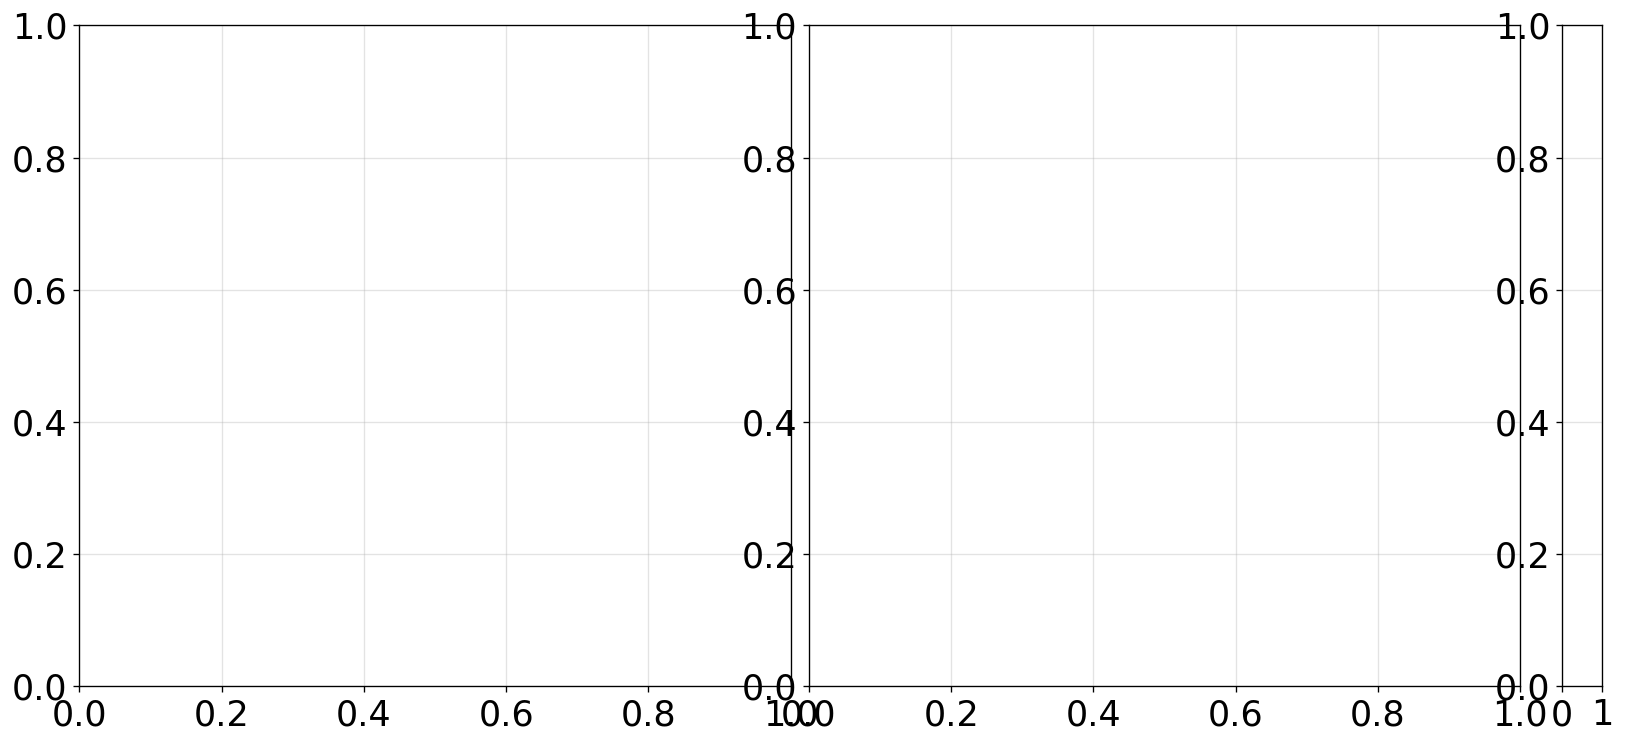

In [ ]:
# ============================================================
# 9. FLOW MAPS WITH ALL PARTICLE CLASSES IN THE SAME SNAPSHOT
#    columns = 3D / 2D
# ============================================================


def plot_clustered_particle_snapshot_panel(flow_var, obs_idx):
    elapsed_days = _snapshot_elapsed_days("3D", obs_idx)

    if flow_var == "ro":
        field_label = "Rossby number"
        cbar_label = r"$\zeta/f$"
        limits = ROSSBY_LIMITS
        cmap = _theme_cmap(["rossby", "vorticity"], "RdBu_r")
    elif flow_var == "div_f":
        field_label = "Normalized divergence"
        cbar_label = r"$\delta/f$"
        limits = DIVERGENCE_LIMITS
        cmap = _theme_cmap(["divergence", "rossby"], "PuOr_r")
    else:
        raise ValueError(f"Unsupported flow variable: {flow_var}")

    fig = plt.figure(figsize=(15.2, 7.2), facecolor="white")
    ax_left = fig.add_axes([0.055, 0.115, 0.390, 0.765])
    ax_right = fig.add_axes([0.455, 0.115, 0.390, 0.765])
    cax = fig.add_axes([0.868, 0.115, 0.022, 0.765])

    pcm = None

    for col, (ax, simulation_label) in enumerate(
        zip([ax_left, ax_right], ["3D", "2D"])
    ):
        sim = simulations[simulation_label]
        field = np.asarray(
            sim["ds_flow"][flow_var].isel(obs=obs_idx).values,
            dtype=float,
        )
        ny, nx = field.shape[-2:]
        x_edges = np.arange(nx + 1) * sim["dx"] / 1000.0
        y_edges = np.arange(ny + 1) * sim["dy"] / 1000.0

        pcm = ax.pcolormesh(
            x_edges,
            y_edges,
            field,
            shading="flat",
            cmap=cmap,
            vmin=limits[0],
            vmax=limits[1],
            zorder=1,
        )

        for particle_tag in common_particle_tags:
            item = coupled_outputs[simulation_label][particle_tag]
            ds_c = item["ds"]
            style = class_style_map[particle_tag]
            x, y = _particle_xy(ds_c, obs_idx)

            # Flat-mesh Parcels positions are stored in metres.
            x = np.mod(x, sim["lx"]) / 1000.0
            y = np.mod(y, sim["ly"]) / 1000.0

            clustered = np.asarray(
                _cluster_flags_for_comparison(
                    simulation_label,
                    particle_tag,
                    obs_idx=obs_idx,
                    as_float=False,
                ),
                dtype=bool,
            ).ravel()

            finite = np.isfinite(x) & np.isfinite(y)

            if SHOW_ALL_PARTICLES_FAINT:
                ax.scatter(
                    x[finite],
                    y[finite],
                    s=0.65 * PARTICLE_POINT_SIZE,
                    marker=style.get("marker", "o"),
                    color=style["color"],
                    alpha=FAINT_POINT_ALPHA,
                    edgecolors="none",
                    zorder=2,
                )

            selected = finite & clustered if PLOT_ONLY_CLUSTERED_PARTICLES else finite
            ax.scatter(
                x[selected],
                y[selected],
                s=PARTICLE_POINT_SIZE,
                marker=style.get("marker", "o"),
                color=style["color"],
                alpha=PARTICLE_POINT_ALPHA,
                edgecolors="none",
                zorder=4,
            )

        shu.format_axis(
            ax,
            title=simulation_label,
            xlabel="x [km]",
            ylabel="y [km]" if col == 0 else None,
            grid=True,
            equal=True,
        )
        enforce_axis_text_sizes(ax)

        if col == 1:
            ax.tick_params(axis="y", labelleft=False)

    colorbar = fig.colorbar(pcm, cax=cax, extend="both")
    colorbar.set_label(cbar_label)
    enforce_colorbar_text_sizes(colorbar)

    legend_handles = []
    for particle_tag in common_particle_tags:
        style = class_style_map[particle_tag]
        legend_handles.append(
            Line2D(
                [0],
                [0],
                linestyle="none",
                marker=style.get("marker", "o"),
                color=style["color"],
                markersize=9,
                label=coupled_outputs["3D"][particle_tag]["label"],
            )
        )

    ax_right.legend(
        handles=legend_handles,
        loc="upper right",
        frameon=True,
        framealpha=0.94,
    )

    fig.suptitle(
        f"{field_label} with clustered particles; "
        f"{RUN_TITLE_INFO} (t = {elapsed_days:g} days)",
        fontsize=PLOT_SIZES["suptitle"],
        y=0.99,
    )

    _save_comparison_figure(
        fig,
        "clustered_particle_snapshots",
        f"{flow_var}_clustered_particles_obs{obs_idx:04d}",
    )
    plt.show()


if PLOT_ROSSBY_OVERLAYS:
    for obs_idx in snapshot_obs_indices:
        plot_clustered_particle_snapshot_panel("ro", obs_idx)

if PLOT_DIVERGENCE_OVERLAYS:
    for obs_idx in snapshot_obs_indices:
        plot_clustered_particle_snapshot_panel("div_f", obs_idx)


Saving frames to: C:\Users\Jelle Gortemaker\Downloads\run_aug1_rossby_frames_zj06iekw


KeyboardInterrupt: 

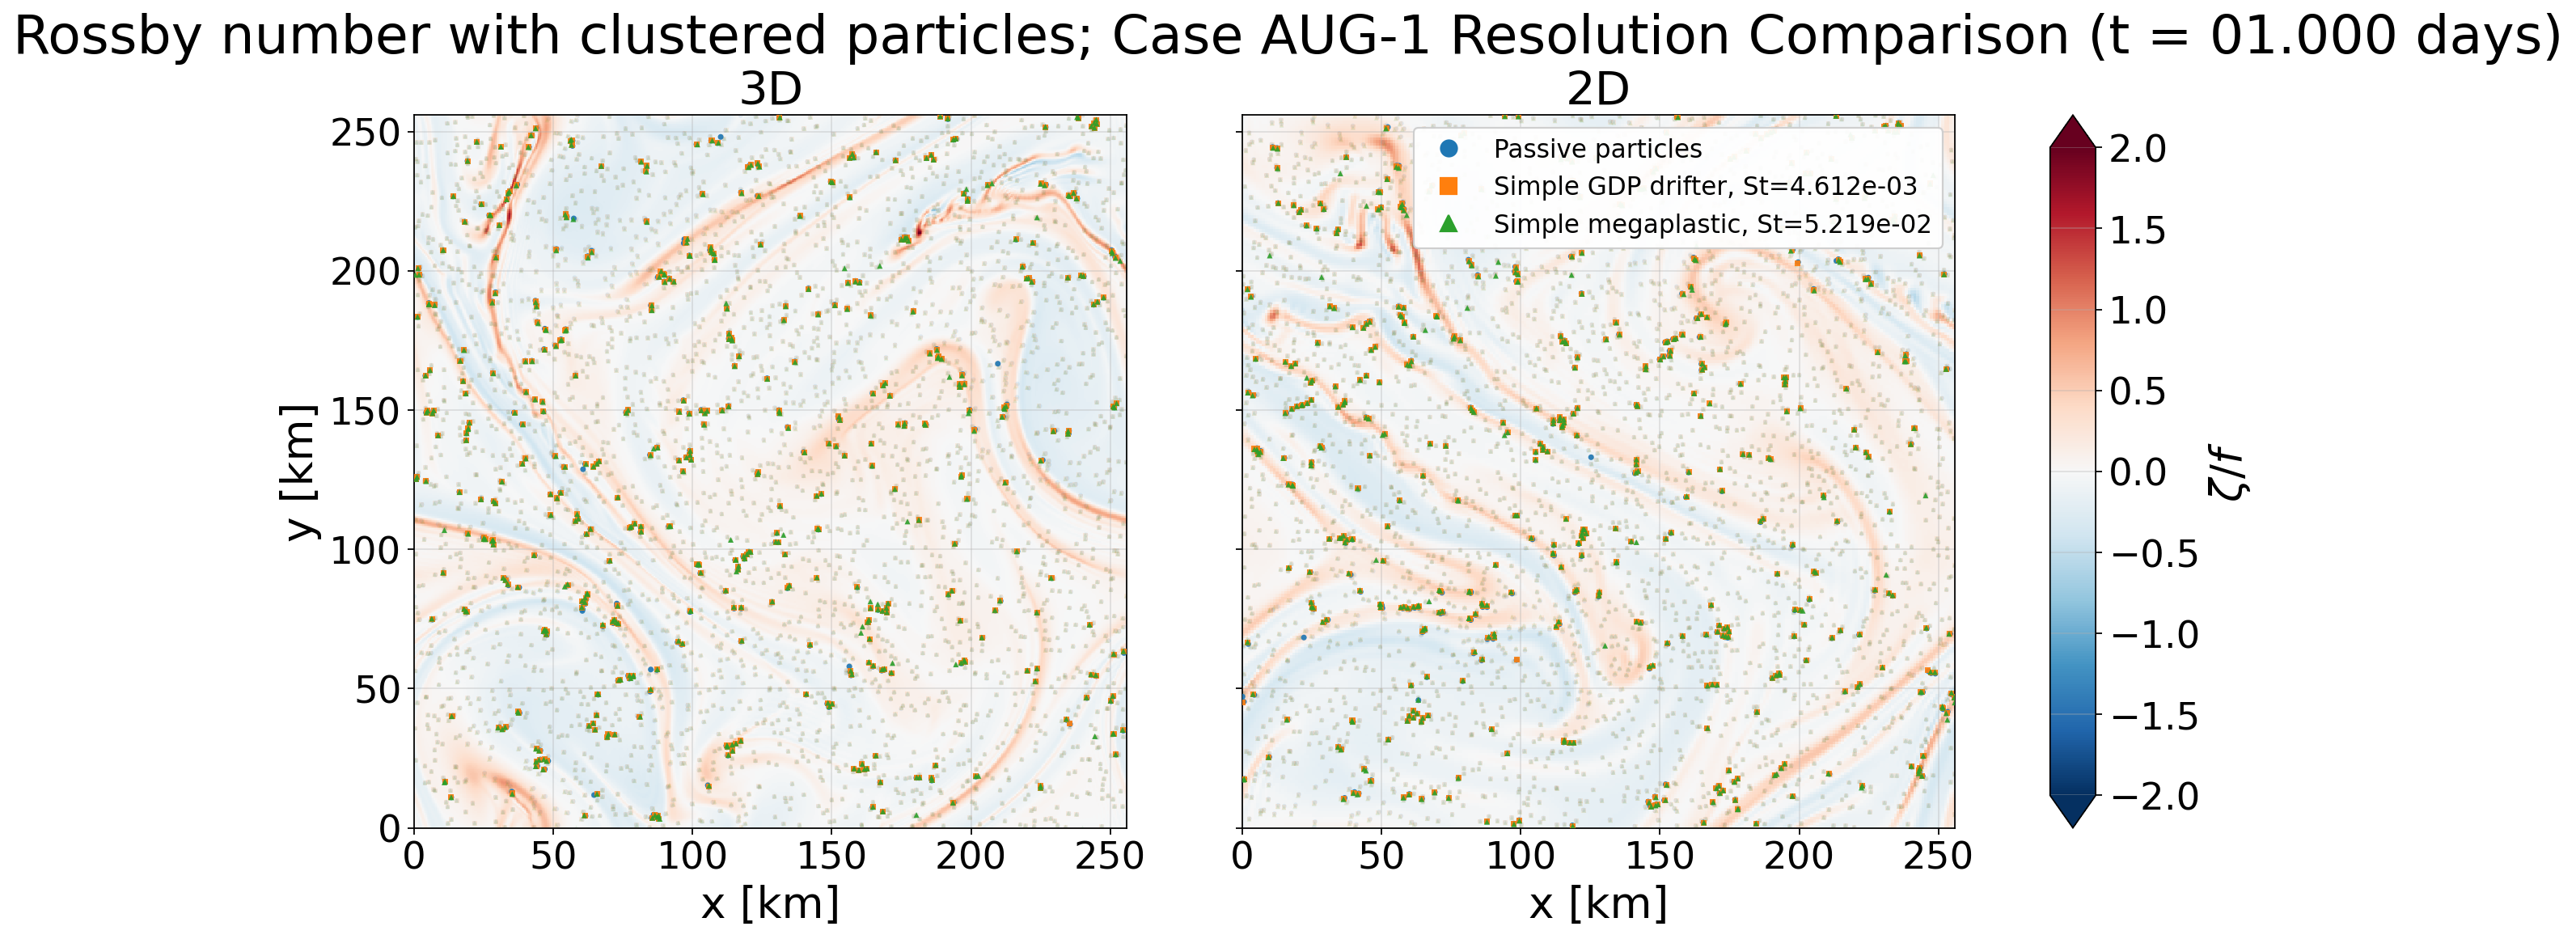

In [ ]:
# ============================================================
# EXPORT ROSSBY CLUSTERED-PARTICLE FRAMES FOR GIF
# Fixed-size frames: suitable for video/GIF creation
# ============================================================

import tempfile
from pathlib import Path
from matplotlib.lines import Line2D

frame_dir = Path(tempfile.mkdtemp(
    prefix=f"{CASE_3D}_rossby_frames_",
    dir=Path.home() / "Downloads",
))
print(f"Saving frames to: {frame_dir}")

FRAME_DPI = 160
FIGSIZE = (16.0, 7.2)

n_obs = min(
    simulations["3D"]["ds_flow"].sizes["obs"],
    simulations["2D"]["ds_flow"].sizes["obs"],
)

for obs_idx in range(n_obs):

    elapsed_days = _snapshot_elapsed_days("3D", obs_idx)

    fig = plt.figure(
        figsize=FIGSIZE,
        dpi=FRAME_DPI,
        facecolor="white",
    )

    ax_left = fig.add_axes([0.055, 0.115, 0.390, 0.765])
    ax_right = fig.add_axes([0.455, 0.115, 0.390, 0.765])
    cax = fig.add_axes([0.868, 0.115, 0.022, 0.765])

    pcm = None

    for col, (ax, sim_label) in enumerate(
        # zip([ax_left, ax_right], ["3D", "2D"])
        zip([ax_left, ax_right], ["500m", "1000m"])
    ):

        sim = simulations[sim_label]

        ro = np.asarray(
            sim["ds_flow"]["ro"].isel(obs=obs_idx).values,
            dtype=float,
        )

        ny, nx = ro.shape[-2:]
        x_edges = np.arange(nx + 1) * sim["dx"] / 1000.0
        y_edges = np.arange(ny + 1) * sim["dy"] / 1000.0

        pcm = ax.pcolormesh(
            x_edges,
            y_edges,
            ro,
            shading="flat",
            cmap=_theme_cmap(["rossby", "vorticity"], "RdBu_r"),
            vmin=ROSSBY_LIMITS[0],
            vmax=ROSSBY_LIMITS[1],
            zorder=1,
        )

        for particle_tag in common_particle_tags:

            ds_c = coupled_outputs[sim_label][particle_tag]["ds"]
            style = class_style_map[particle_tag]

            x, y = _particle_xy(ds_c, obs_idx)
            x = np.mod(x, sim["lx"]) / 1000.0
            y = np.mod(y, sim["ly"]) / 1000.0

            clustered = np.asarray(
                _cluster_flags_for_comparison(
                    sim_label,
                    particle_tag,
                    obs_idx=obs_idx,
                    as_float=False,
                ),
                dtype=bool,
            ).ravel()

            finite = np.isfinite(x) & np.isfinite(y)

            if SHOW_ALL_PARTICLES_FAINT:
                ax.scatter(
                    x[finite],
                    y[finite],
                    s=0.65 * PARTICLE_POINT_SIZE,
                    marker=style.get("marker", "o"),
                    color=style["color"],
                    alpha=FAINT_POINT_ALPHA,
                    edgecolors="none",
                    zorder=2,
                )

            ax.scatter(
                x[finite & clustered],
                y[finite & clustered],
                s=PARTICLE_POINT_SIZE,
                marker=style.get("marker", "o"),
                color=style["color"],
                alpha=PARTICLE_POINT_ALPHA,
                edgecolors="none",
                zorder=4,
            )

        shu.format_axis(
            ax,
            title=sim_label,
            xlabel="x [km]",
            ylabel="y [km]" if col == 0 else None,
            grid=True,
            equal=True,
        )

        enforce_axis_text_sizes(ax)

        ax.set_xlim(0, sim["lx"] / 1000.0)
        ax.set_ylim(0, sim["ly"] / 1000.0)

        if col == 1:
            ax.tick_params(axis="y", labelleft=False)

    colorbar = fig.colorbar(
        pcm,
        cax=cax,
        extend="both",
    )
    colorbar.set_label(r"$\zeta/f$")
    enforce_colorbar_text_sizes(colorbar)

    ax_right.legend(
        handles=[
            Line2D(
                [0],
                [0],
                linestyle="none",
                marker=class_style_map[tag].get("marker", "o"),
                color=class_style_map[tag]["color"],
                markersize=9,
                label=coupled_outputs["3D"][tag]["label"],
            )
            for tag in common_particle_tags
        ],
        loc="upper right",
        frameon=True,
        framealpha=0.94,
    )

    fig.suptitle(
        f"Rossby number with clustered particles; "
        f"{RUN_TITLE_INFO} (t = {elapsed_days:06.3f} days)",
        fontsize=PLOT_SIZES["suptitle"],
        y=0.99,
    )

    fig.savefig(
        frame_dir / f"rossby_clustered_particles_{obs_idx:04d}.png",
        dpi=FRAME_DPI,
        facecolor="white",
    )

    plt.close(fig)

print(f"Saved {n_obs} fixed-size frames to: {frame_dir}")

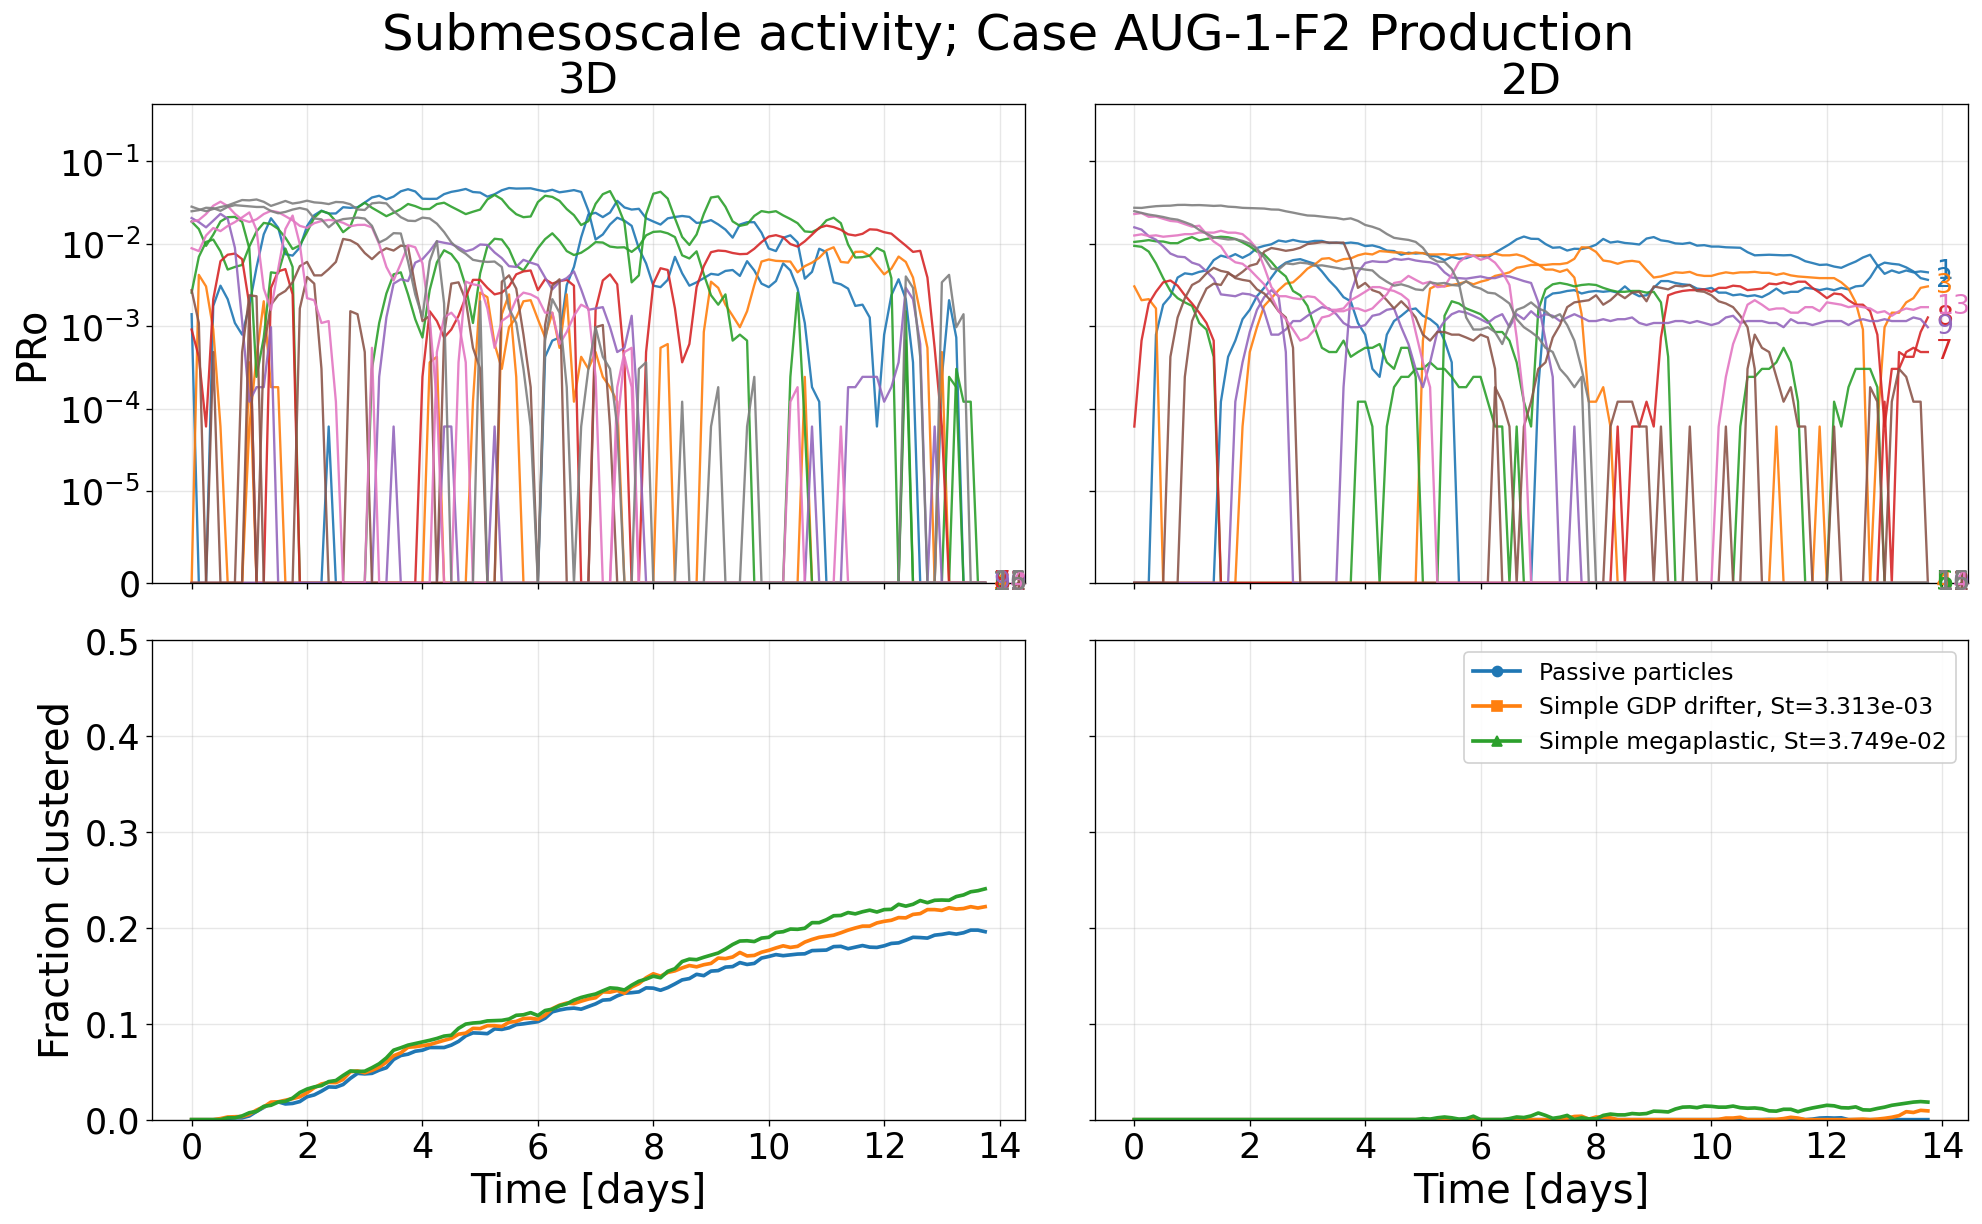

In [ ]:
# ============================================================
# 10. TEMPORAL EVOLUTION:
#     LOCAL SUBMESOSCALE ACTIVITY AND CLUSTER FRACTION
#     rows = diagnostic, columns = 3D / 2D
# ============================================================

N_SQUARES_X = 4
N_SQUARES_Y = 4


def _local_pro_table(simulation_label):
    sim = simulations[simulation_label]
    ro_all = np.asarray(sim["ds_flow"]["ro"].values, dtype=float)
    t_days = np.asarray(sim["ds_flow"]["elapsed_days"].values, dtype=float)

    _, ny, nx = ro_all.shape
    squares, _, _ = shu.build_square_index_ranges(
        ny,
        nx,
        N_SQUARES_Y,
        N_SQUARES_X,
    )

    records = []
    for j, obs_value in enumerate(sim["ds_flow"]["obs"].values):
        for result in shu.compute_pro_per_square(
            ro_all[j],
            squares,
            SUBMESO_RO_THRESHOLD,
        ):
            records.append({
                "obs": int(obs_value),
                "elapsed_days": float(t_days[j]),
                "square_id": int(result["square_id"]),
                "PRo": float(result["PRo"]),
            })

    table = pd.DataFrame(records)
    return (
        table
        .pivot(index="elapsed_days", columns="square_id", values="PRo")
        .sort_index()
    )


if PLOT_CLUSTER_FRACTION_VS_SUBMESO_ACTIVITY:
    local_pro = {
        label: _local_pro_table(label)
        for label in ("3D", "2D")
    }

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(17.0, 10.2),
        sharex="col",
        sharey="row",
        facecolor="white",
        gridspec_kw={"hspace": 0.12, "wspace": 0.08},
    )

    categorical_cmap = shu.get_cmap("categorical")

    for col, simulation_label in enumerate(("3D", "2D")):
        # ----------------------------------------------------
        # Local PRo
        # ----------------------------------------------------
        ax = axes[0, col]
        table = local_pro[simulation_label]

        for i, square_id in enumerate(table.columns):
            x = np.asarray(table.index.values, dtype=float)
            y = np.asarray(table[square_id].values, dtype=float)
            color = categorical_cmap((i % 20) / 19) if callable(categorical_cmap) else None

            ax.plot(x, y, color=color, lw=1.4, alpha=0.90)

            finite = np.isfinite(y)
            if np.any(finite):
                last = np.where(finite)[0][-1]
                ax.annotate(
                    str(int(square_id)),
                    xy=(x[last], y[last]),
                    xytext=(5, 0),
                    textcoords="offset points",
                    color=color,
                    fontsize=PLOT_SIZES["annotation"] - 3,
                    va="center",
                    clip_on=False,
                )

        ax.set_title(simulation_label)
        ax.set_ylabel("PRo" if col == 0 else "")
        ax.set_yscale("symlog", linthresh=1.0e-5)
        ax.set_ylim(*PRO_YLIM)
        ax.grid(True, alpha=0.30)
        enforce_axis_text_sizes(ax)

        if col == 1:
            ax.tick_params(axis="y", labelleft=False)

        # ----------------------------------------------------
        # Fraction clustered
        # ----------------------------------------------------
        ax = axes[1, col]
        for particle_tag in common_particle_tags:
            item = coupled_outputs[simulation_label][particle_tag]
            ds_c = item["ds"]
            style = class_style_map[particle_tag]
            cluster_flags = np.asarray(
                _cluster_flags_for_comparison(
                    simulation_label,
                    particle_tag,
                    as_float=True,
                ),
                dtype=float,
            )
            fraction_clustered = np.nanmean(
                cluster_flags,
                axis=0,
            )

            if NORMALIZE_CLUSTER_FRACTION_TO_INITIAL:
                finite_initial = np.isfinite(fraction_clustered)
                initial_value = (
                    float(fraction_clustered[finite_initial][0])
                    if np.any(finite_initial)
                    else 0.0
                )
                fraction_clustered = np.clip(
                    fraction_clustered - initial_value,
                    0.0,
                    1.0,
                )

            ax.plot(
                np.asarray(ds_c["elapsed_days"].values, dtype=float),
                fraction_clustered,
                color=style["color"],
                lw=2.2,
                label=item["label"],
            )

        ax.set_xlabel("Time [days]")
        ax.set_ylabel("Fraction clustered" if col == 0 else "")
        ax.set_ylim(*CLUSTER_FRACTION_YLIM)
        ax.grid(True, alpha=0.30)
        enforce_axis_text_sizes(ax)

        if col == 1:
            ax.tick_params(axis="y", labelleft=False)

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=class_style_map[tag]["color"],
            marker=class_style_map[tag].get("marker", "o"),
            lw=2.2,
            label=coupled_outputs["3D"][tag]["label"],
        )
        for tag in common_particle_tags
    ]
    axes[1, 1].legend(
        handles=legend_handles,
        loc="upper right",
        frameon=True,
    )

    fig.suptitle(
        "Submesoscale activity; "
        f"{RUN_TITLE_INFO}",
        fontsize=PLOT_SIZES["suptitle"],
        y=0.985,
    )
    fig.subplots_adjust(left=0.08, right=0.97, bottom=0.08, top=0.91)

    _save_comparison_figure(
        fig,
        "timeseries",
        f"local_pro_and_cluster_fraction_{N_SQUARES_X}x{N_SQUARES_Y}",
    )
    plt.show()


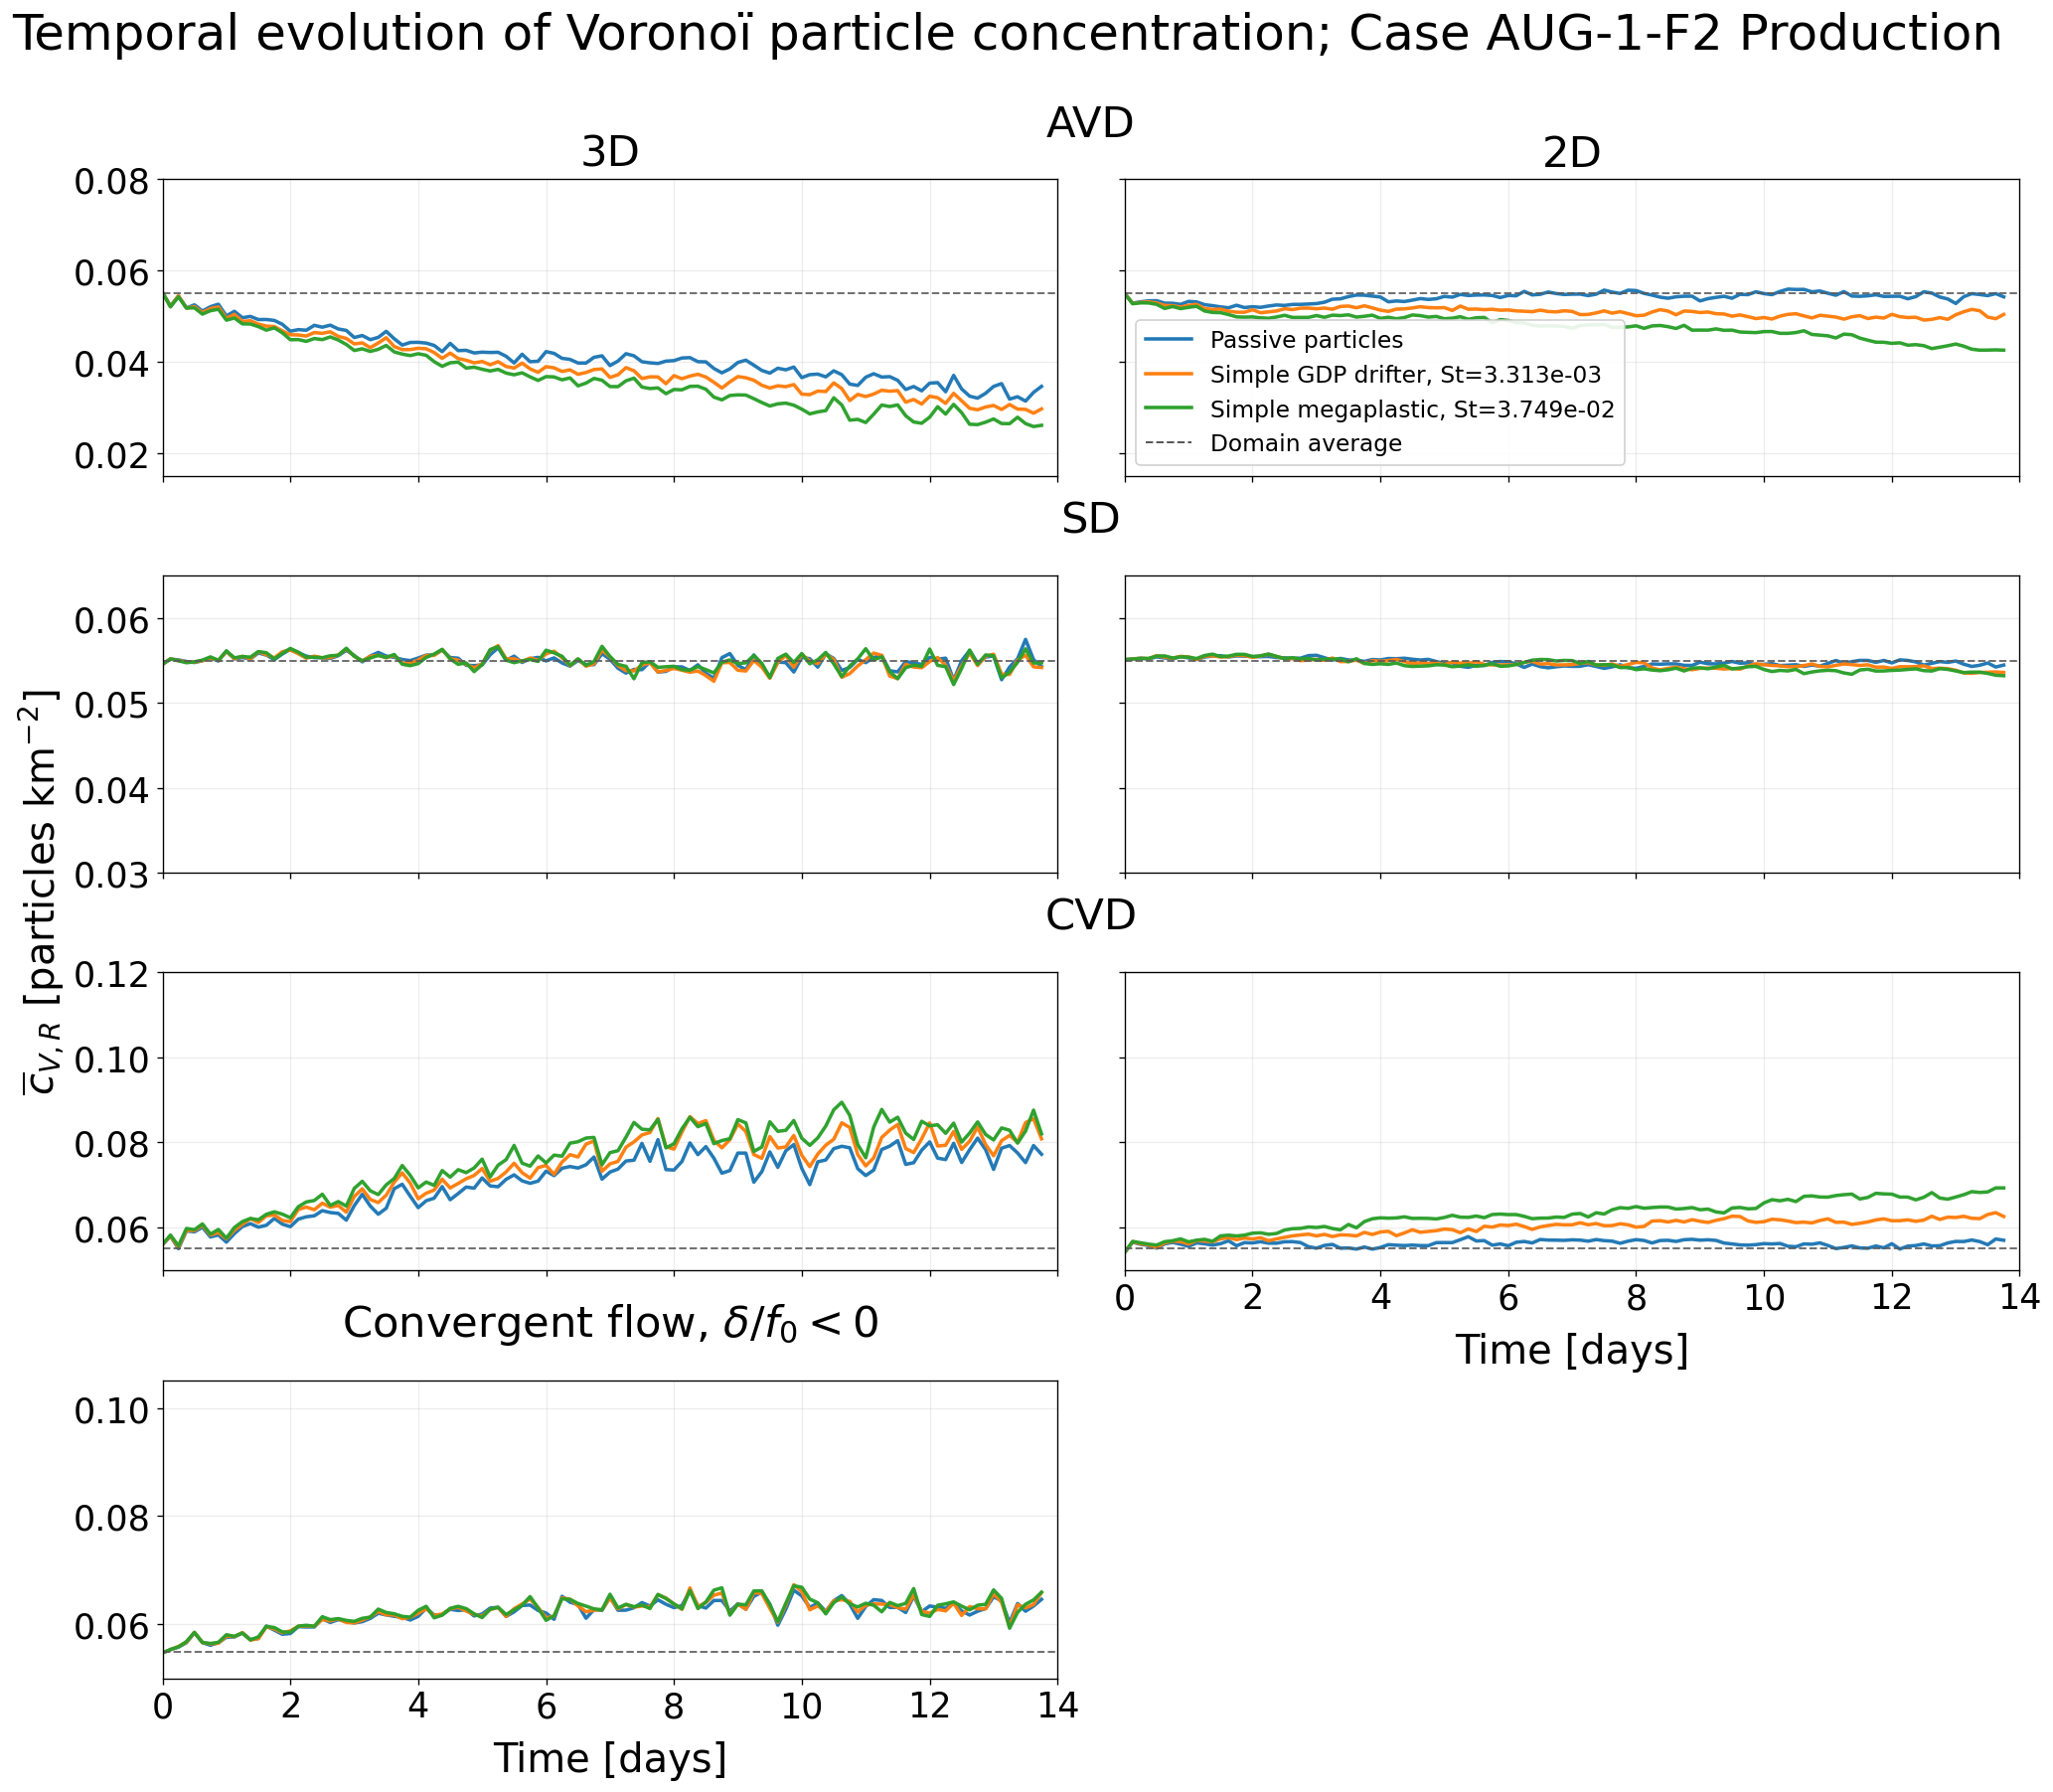

In [ ]:
# ============================================================
# 11. TEMPORAL EVOLUTION OF VORONOÏ PARTICLE CONCENTRATION
#     BY FLOW CONDITION
# ============================================================

CONVERGENCE_THRESHOLD = 0.0
PLOT_CONVERGENCE_STRENGTH = False


def _selected_voronoi_concentration(mask, area_m2):
    valid = (
        np.asarray(mask, dtype=bool)
        & np.isfinite(area_m2)
        & (area_m2 > 0.0)
    )

    n_selected = int(np.count_nonzero(valid))

    if n_selected == 0:
        return np.nan

    selected_area_km2 = (
        np.nansum(area_m2[valid]) / 1.0e6
    )

    if (
        not np.isfinite(selected_area_km2)
        or selected_area_km2 <= 0.0
    ):
        return np.nan

    return n_selected / selected_area_km2


def _concentration_by_flow_condition(
    simulation_label,
):
    panel_keys = ["AVD", "SD", "CVD"]

    if simulation_label == "3D":
        panel_keys.append("CONV")

    result = {
        key: {}
        for key in panel_keys
    }

    for particle_tag in common_particle_tags:
        ds_c = coupled_outputs[
            simulation_label
        ][particle_tag]["ds"]

        ro_p = np.asarray(
            ds_c["ro_particle"].values,
            dtype=float,
        )

        strain_p = np.asarray(
            ds_c["strain_f_particle"].values,
            dtype=float,
        )

        area_m2 = np.asarray(
            ds_c["voronoi_area"].values,
            dtype=float,
        )

        div_p = (
            np.asarray(
                ds_c["div_f_particle"].values,
                dtype=float,
            )
            if simulation_label == "3D"
            else None
        )

        class_values = {
            key: np.full(
                ds_c.sizes["obs"],
                np.nan,
                dtype=float,
            )
            for key in panel_keys
        }

        for obs_index in range(
            ds_c.sizes["obs"]
        ):
            regime_masks = (
                phelp.particle_regime_masks(
                    ro_p[:, obs_index],
                    strain_p[:, obs_index],
                )
            )

            masks = {
                "AVD": regime_masks["AVD"],
                "SD": regime_masks["SD"],
                "CVD": regime_masks["CVD"],
            }

            if simulation_label == "3D":
                masks["CONV"] = (
                    np.isfinite(
                        div_p[:, obs_index]
                    )
                    & (
                        div_p[:, obs_index]
                        < -float(
                            CONVERGENCE_THRESHOLD
                        )
                    )
                )

            for panel_key in panel_keys:
                class_values[
                    panel_key
                ][obs_index] = (
                    _selected_voronoi_concentration(
                        masks[panel_key],
                        area_m2[:, obs_index],
                    )
                )

        for panel_key in panel_keys:
            result[
                panel_key
            ][particle_tag] = (
                class_values[panel_key]
            )

    return result

if PLOT_REGIME_CONCENTRATION_TIMESERIES:
    # Fixed limits used for every case.
    regime_y_limits = REGIME_CONCENTRATION_YLIMS

    time_limits = (0.0, 14.0)

    panel_specs = [
        ("AVD", "AVD"),
        ("SD", "SD"),
        ("CVD", "CVD"),
        (
            "CONV",
            (
                r"Convergent flow, $\delta/f_0<0$"
                if np.isclose(
                    CONVERGENCE_THRESHOLD,
                    0.0,
                )
                else (
                    rf"Convergent flow, "
                    rf"$\delta/f_0"
                    rf"<-{CONVERGENCE_THRESHOLD:g}$"
                )
            ),
        ),
    ]

    concentration = {
        simulation_label:
        _concentration_by_flow_condition(
            simulation_label
        )
        for simulation_label in ("3D", "2D")
    }

    domain_mean = {}

    for simulation_label in ("3D", "2D"):
        simulation = simulations[
            simulation_label
        ]

        ds_reference = coupled_outputs[
            simulation_label
        ][common_particle_tags[0]]["ds"]

        domain_area_km2 = (
            simulation["lx"]
            * simulation["ly"]
        ) / 1.0e6

        domain_mean[simulation_label] = (
            ds_reference.sizes["trajectory"]
            / domain_area_km2
        )

    # ------------------------------------------------------------
    # Dedicated title rows prevent overlap between:
    # - regime titles,
    # - x tick labels,
    # - x-axis labels.
    #
    # The convergence title and plot occupy only column 0.
    # ------------------------------------------------------------
    fig = plt.figure(
        figsize=(17.5, 15.0),
        facecolor="white",
    )

    grid = fig.add_gridspec(
        nrows=8,
        ncols=2,
        height_ratios=[
            0.11, 1.0,
            0.11, 1.0,
            0.11, 1.0,
            0.15, 1.0,
        ],
        hspace=0.20,
        wspace=0.075,
    )

    axes = np.empty(
        (len(panel_specs), 2),
        dtype=object,
    )

    title_axes = []

    for row, (_, panel_title) in enumerate(
        panel_specs
    ):
        if row < 3:
            # AVD, SD and CVD span both columns.
            title_axis = fig.add_subplot(
                grid[2 * row, :]
            )
        else:
            # Convergence belongs only to the 3D column.
            title_axis = fig.add_subplot(
                grid[2 * row, 0]
            )

            empty_title_axis = fig.add_subplot(
                grid[2 * row, 1]
            )
            empty_title_axis.set_axis_off()

        title_axis.set_axis_off()

        title_axis.text(
            0.5,
            0.03,
            panel_title,
            ha="center",
            va="bottom",
            fontsize=PLOT_SIZES["title"],
        )

        title_axes.append(title_axis)

        axes[row, 0] = fig.add_subplot(
            grid[2 * row + 1, 0]
        )

        axes[row, 1] = fig.add_subplot(
            grid[2 * row + 1, 1],
            sharey=axes[row, 0],
        )

    axes[0, 0].set_title(
        "3D",
        fontsize=PLOT_SIZES["title"],
        pad=8,
    )

    axes[0, 1].set_title(
        "2D",
        fontsize=PLOT_SIZES["title"],
        pad=8,
    )

    for row, (panel_key, _) in enumerate(
        panel_specs
    ):
        for col, simulation_label in enumerate(
            ("3D", "2D")
        ):
            ax = axes[row, col]
            ax.set_facecolor("white")

            # The 2D convergence panel is deliberately absent.
            if (
                panel_key == "CONV"
                and simulation_label == "2D"
            ):
                ax.set_axis_off()
                continue

            for particle_tag in common_particle_tags:
                ds_c = coupled_outputs[
                    simulation_label
                ][particle_tag]["ds"]

                elapsed_days = np.asarray(
                    ds_c["elapsed_days"].values,
                    dtype=float,
                )

                values = concentration[
                    simulation_label
                ][panel_key][particle_tag]

                style = class_style_map[
                    particle_tag
                ]

                ax.plot(
                    elapsed_days,
                    values,
                    color=style["color"],
                    lw=2.1,
                    alpha=0.98,
                )

            ax.axhline(
                domain_mean[
                    simulation_label
                ],
                color="0.35",
                lw=1.2,
                ls="--",
                alpha=0.85,
            )

            ax.set_xlim(*time_limits)

            ax.set_ylim(
                *regime_y_limits[panel_key]
            )

            ax.grid(
                True,
                alpha=0.22,
            )

            ax.ticklabel_format(
                axis="y",
                style="plain",
                useOffset=False,
            )

            enforce_axis_text_sizes(ax)

            if col == 1:
                ax.tick_params(
                    axis="y",
                    labelleft=False,
                )

            # Lowest visible panel in each column:
            #
            # left column  -> convergence row
            # right column -> CVD row
            show_bottom_axis = (
                (
                    panel_key == "CONV"
                    and col == 0
                )
                or
                (
                    panel_key == "CVD"
                    and col == 1
                )
            )

            ax.tick_params(
                axis="x",
                labelbottom=show_bottom_axis,
            )

            if show_bottom_axis:
                ax.set_xlabel(
                    "Time [days]",
                    fontsize=PLOT_SIZES["label"],
                    labelpad=10,
                )
            else:
                ax.set_xlabel("")

    # The lower-right axis must not retain any labels or ticks.
    axes[3, 1].set_axis_off()

    fig.supylabel(
        r"$\overline{c}_{V,R}$ "
        r"[particles km$^{-2}$]",
        fontsize=PLOT_SIZES["label"],
        x=0.025,
    )

    # ------------------------------------------------------------
    # One particle-class legend in the upper-right 2D panel
    # ------------------------------------------------------------
    legend_handles = [
        Line2D(
            [0],
            [0],
            color=class_style_map[
                particle_tag
            ]["color"],
            lw=2.1,
            label=coupled_outputs[
                "3D"
            ][particle_tag]["label"],
        )
        for particle_tag in common_particle_tags
    ]

    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="0.35",
            lw=1.2,
            ls="--",
            label="Domain average",
        )
    )

    axes[0, 1].legend(
        handles=legend_handles,
        loc="lower left",
        frameon=True,
        fontsize=PLOT_SIZES["legend"],
        title_fontsize=PLOT_SIZES["legend"],
    )

    fig.suptitle(
        "Temporal evolution of Voronoï particle concentration; "
        f"{RUN_TITLE_INFO}",
        fontsize=PLOT_SIZES["suptitle"],
        y=0.992,
    )

    # No tight_layout call: it would alter the controlled spacing.
    fig.subplots_adjust(
        left=0.095,
        right=0.985,
        bottom=0.060,
        top=0.935,
    )

    _save_comparison_figure(
        fig,
        "timeseries",
        "voronoi_concentration_by_flow_condition",
    )

    plt.show()

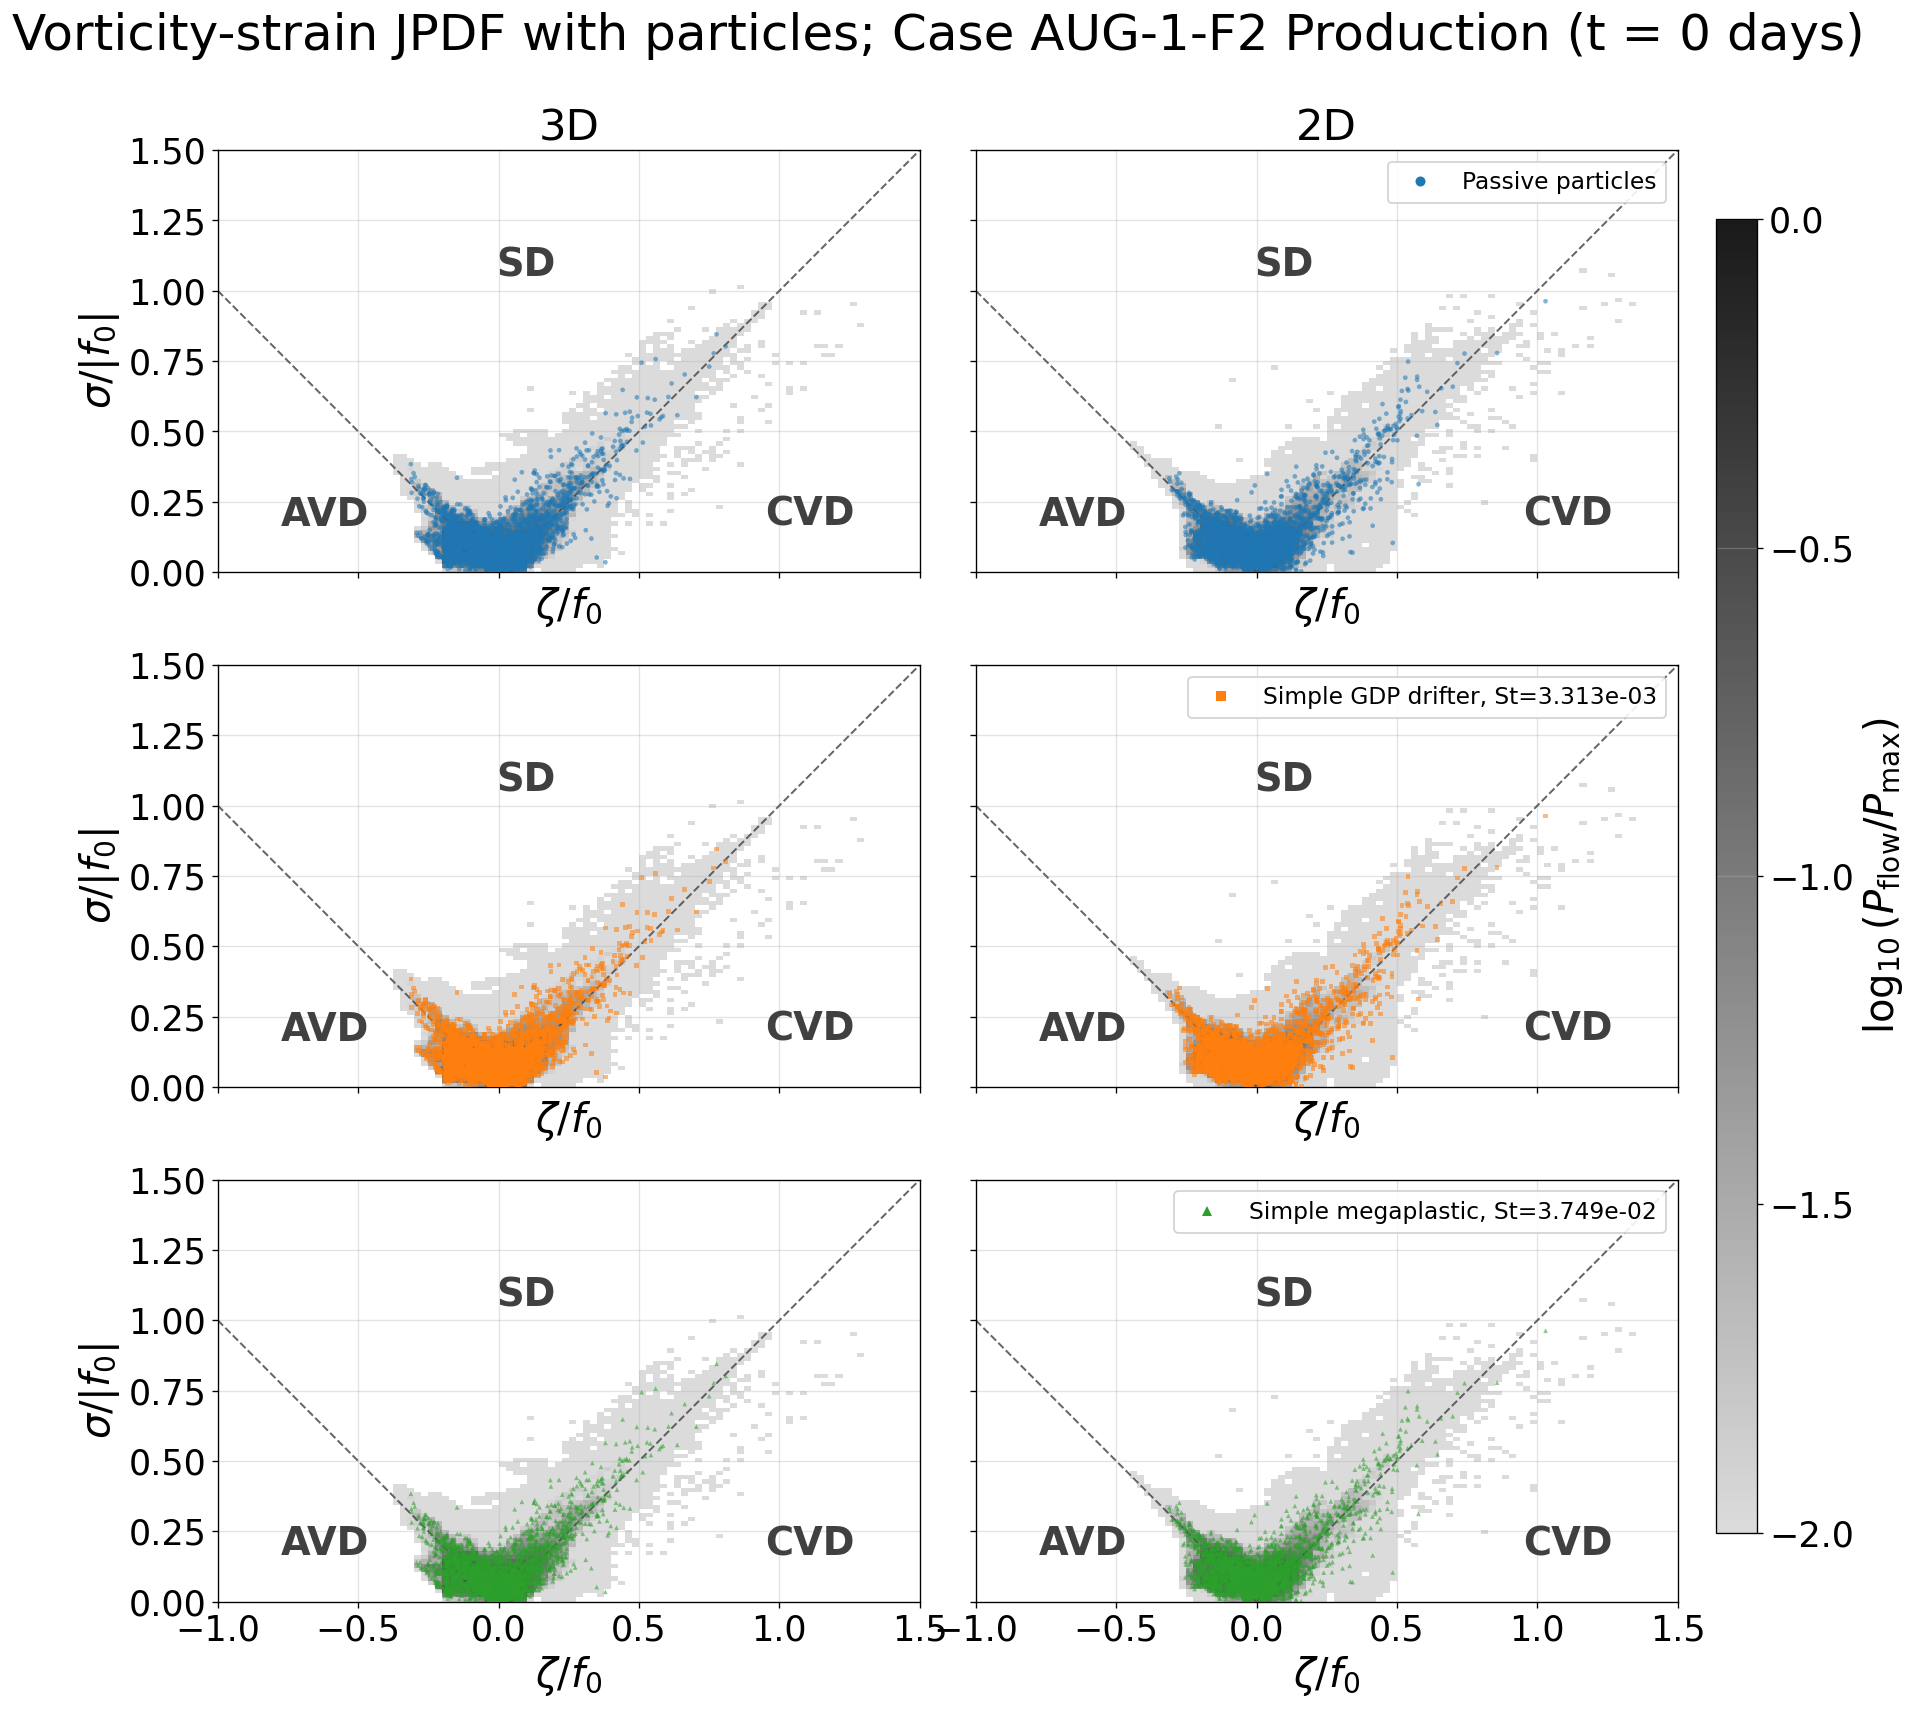

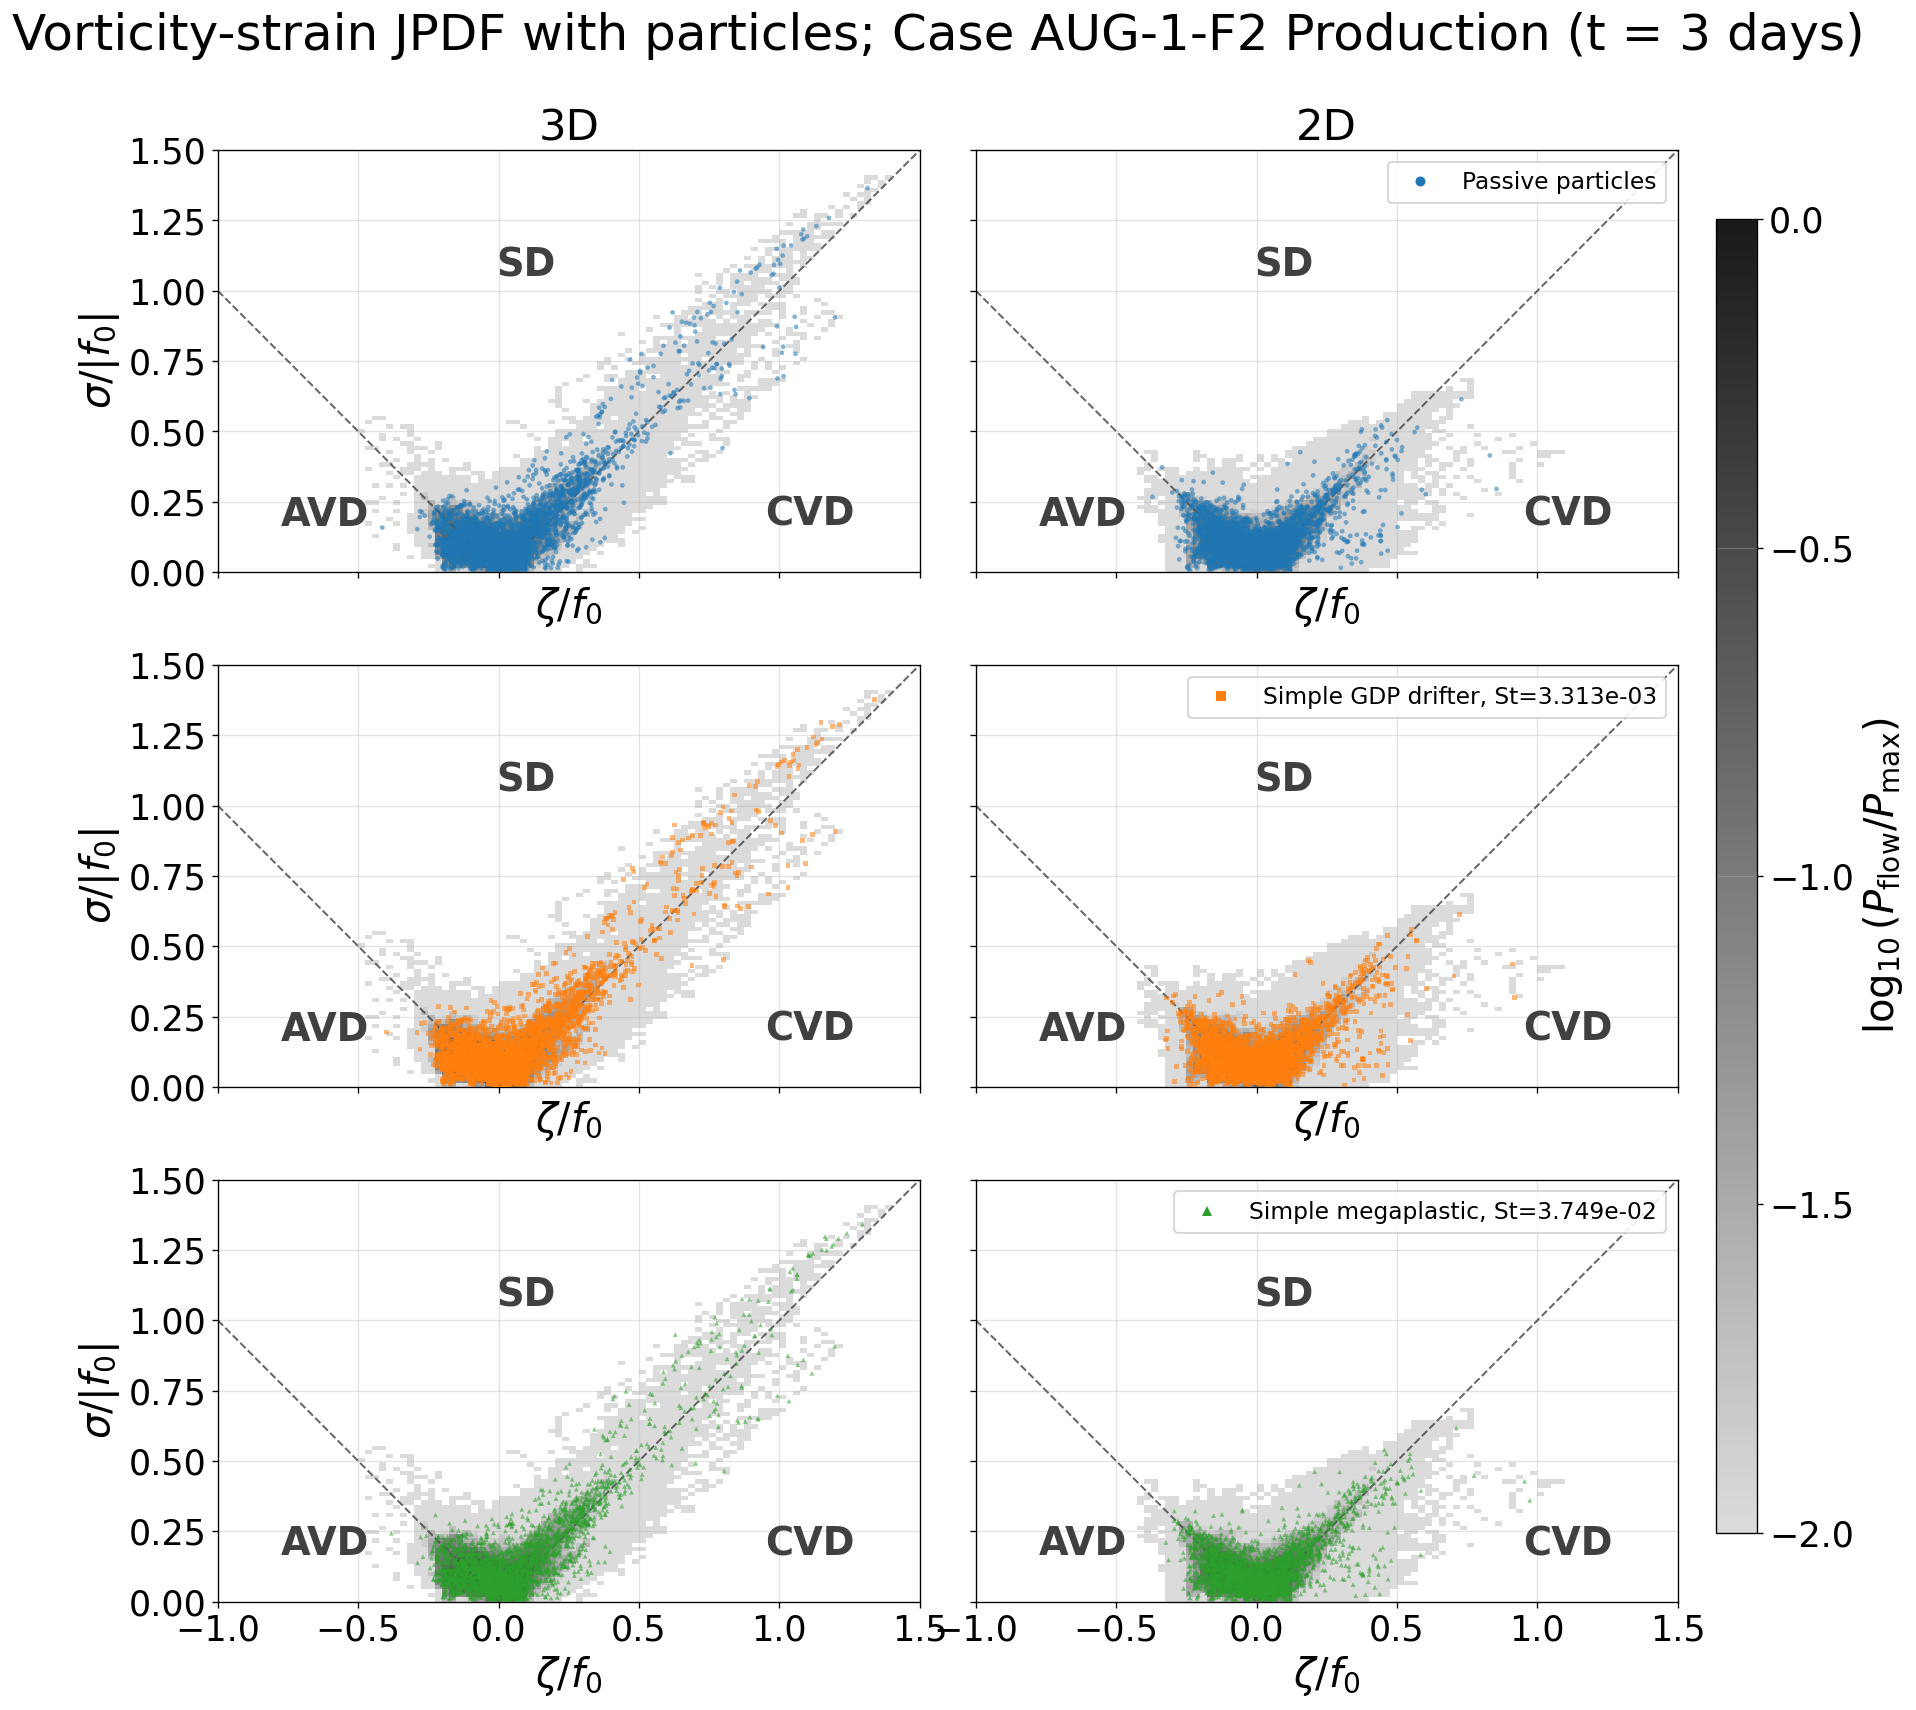

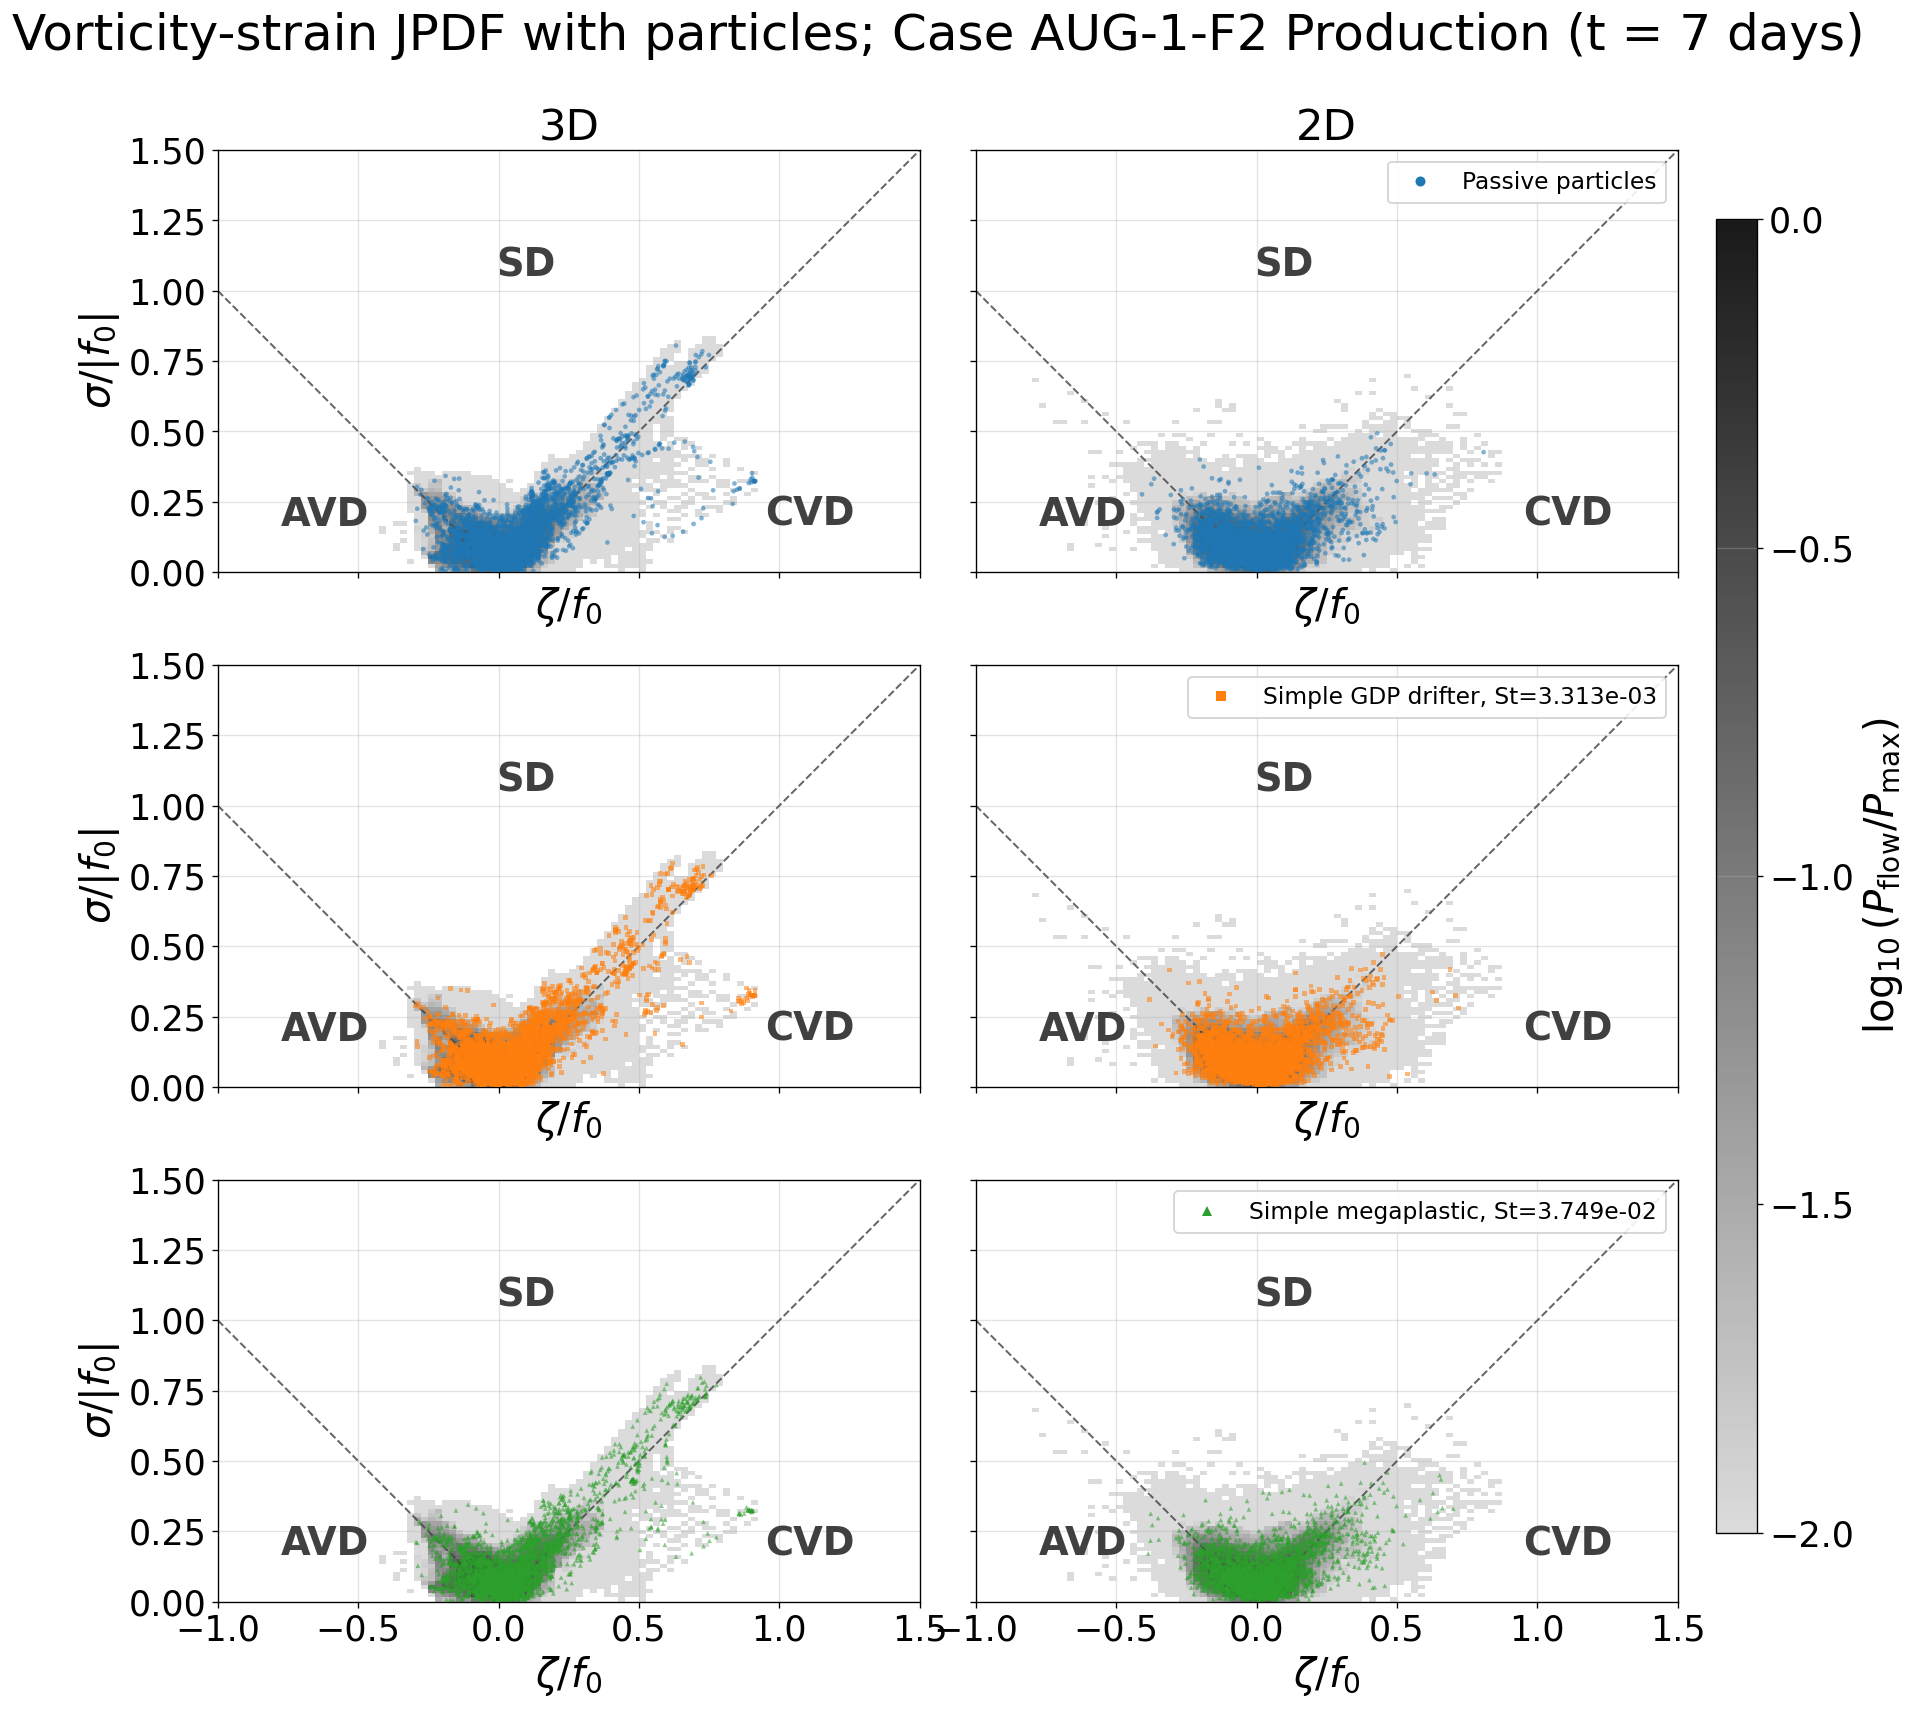

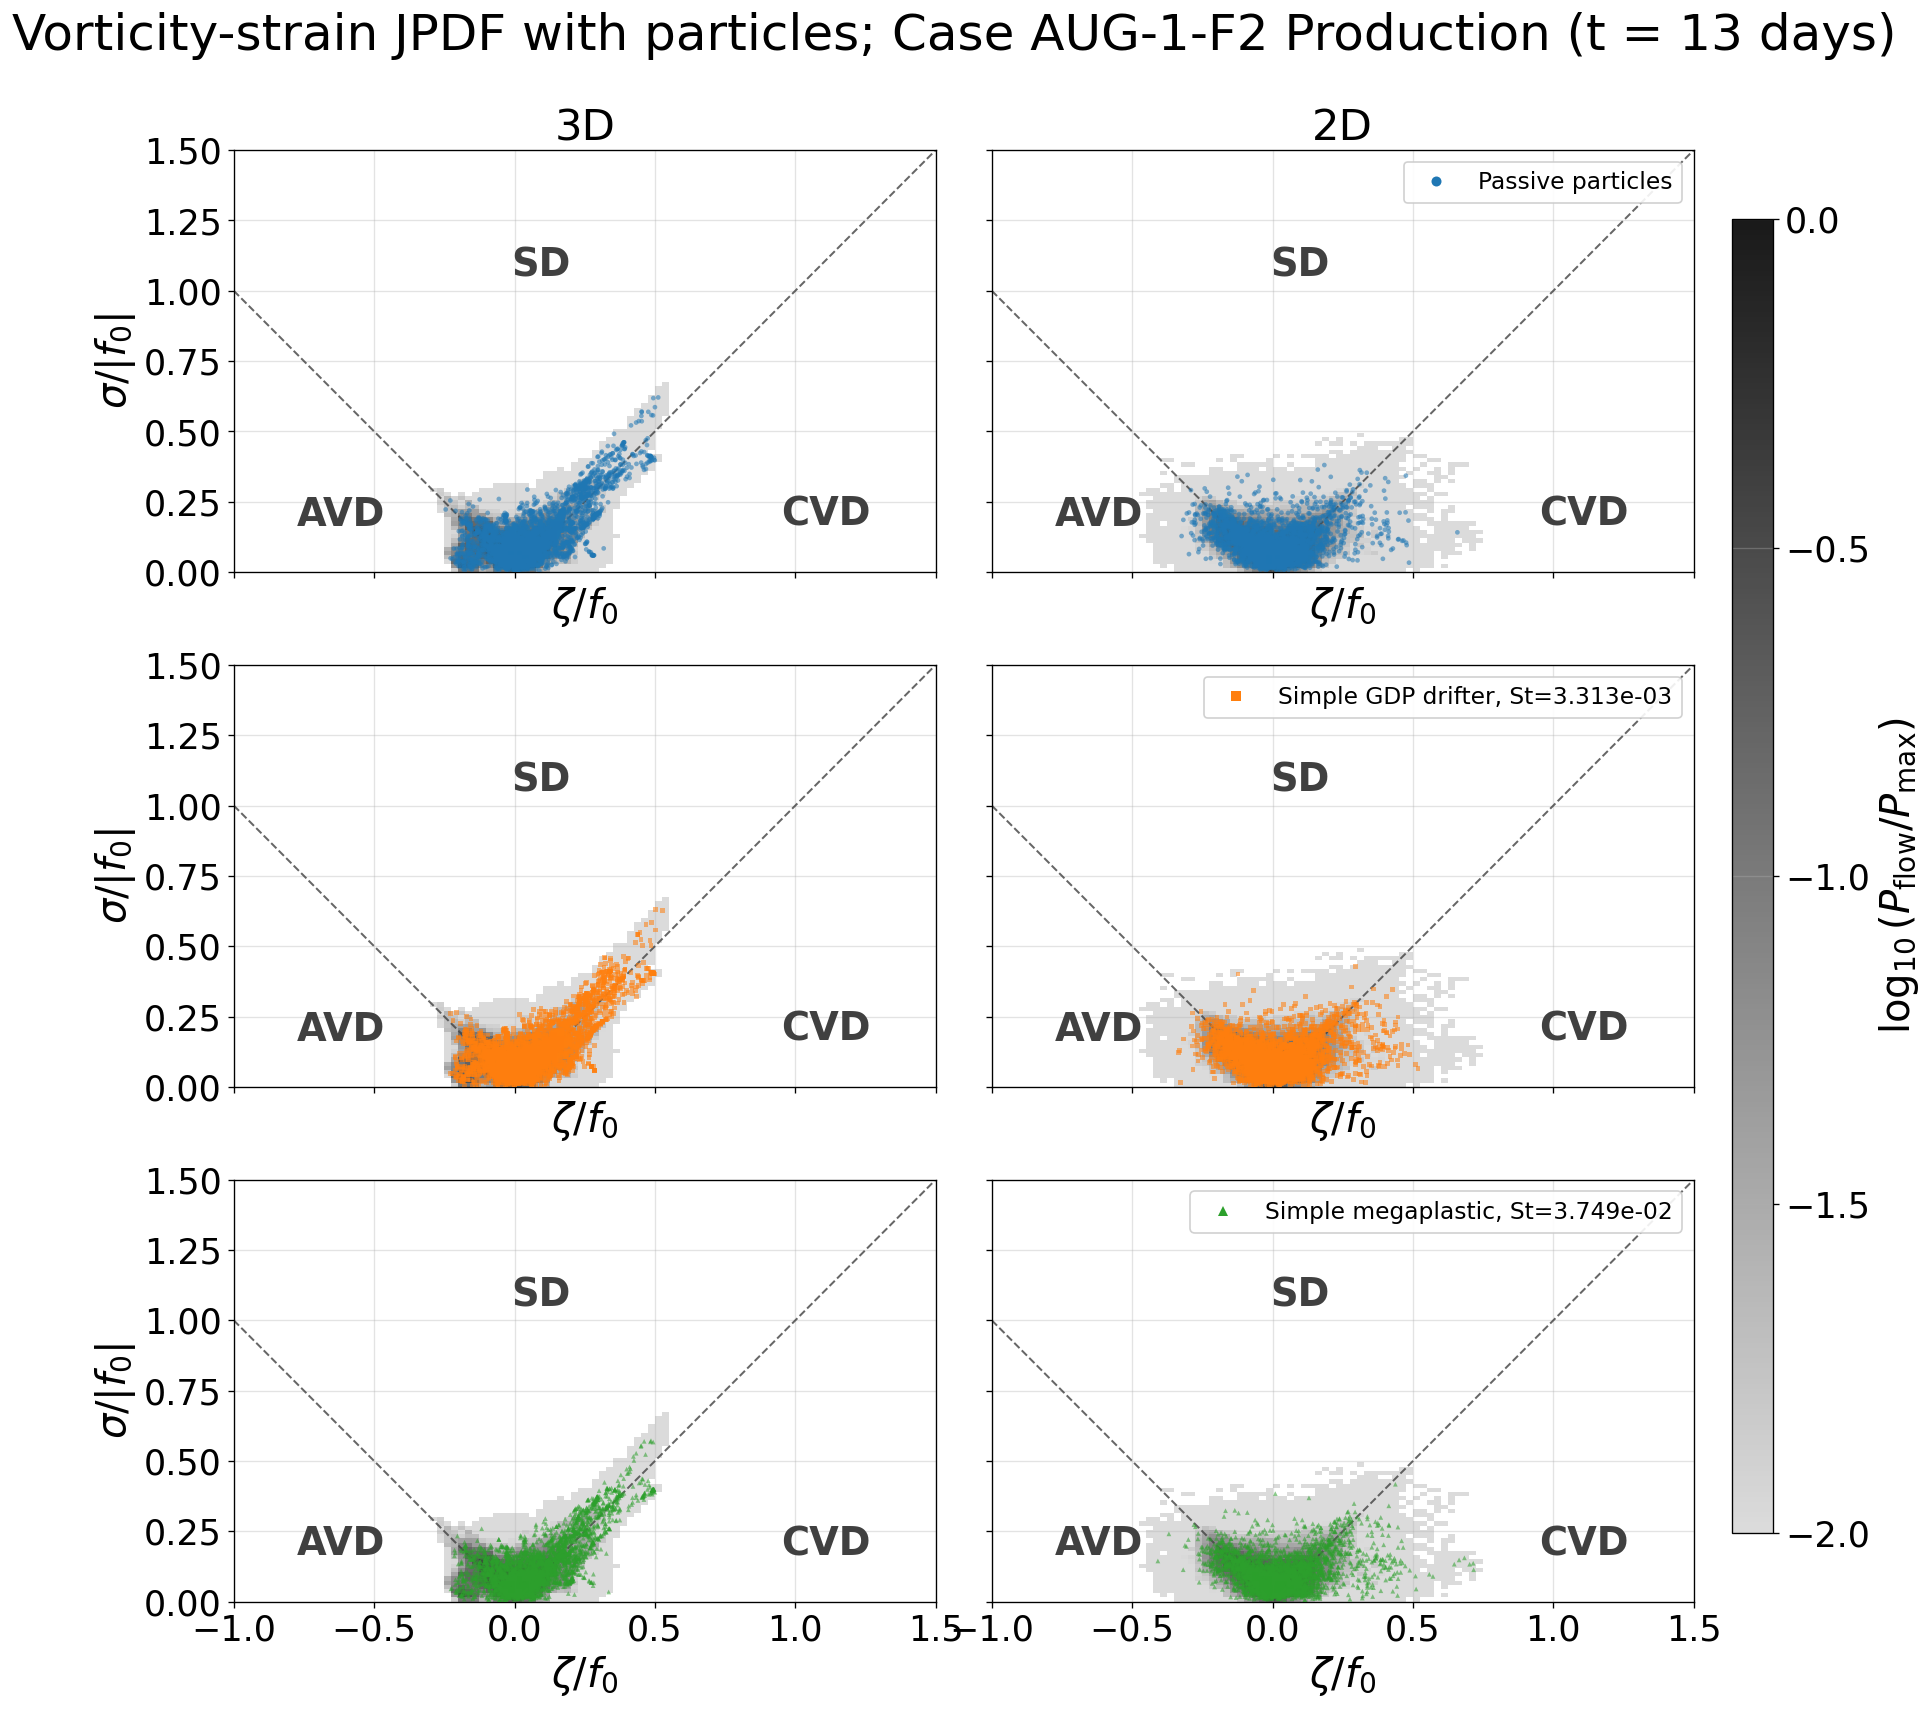

In [ ]:
# ============================================================
# 12. PARTICLE-SAMPLED VORTICITY--STRAIN JPDFs
# ============================================================


def _log_relative_probability_from_counts(counts):
    result = np.full(counts.shape, np.nan, dtype=float)
    total = float(np.sum(counts))

    if total > 0.0:
        probability = counts / total
        positive = probability > 0.0
        result[positive] = np.log10(
            probability[positive] / np.nanmax(probability)
        )

    return result


def _format_particle_jpdf_axis(ax, column_label=None, show_ylabel=True):
    ax.set_xlim(RS_RO_LIMITS)
    ax.set_ylim(RS_STRAIN_LIMITS)
    ax.set_xlabel(r"$\zeta/f_0$")
    ax.set_ylabel(r"$\sigma/|f_0|$" if show_ylabel else "")
    ax.grid(True, alpha=getattr(ptheme, "GRID_ALPHA", 0.30))
    ax.set_facecolor("white")
    _draw_ro_strain_regimes(ax, RS_RO_LIMITS, RS_STRAIN_LIMITS)
    enforce_axis_text_sizes(ax)

    if column_label is not None:
        ax.set_title(column_label)


if PLOT_PARTICLE_SAMPLED_JPDF:
    ro_edges = np.linspace(RS_RO_LIMITS[0], RS_RO_LIMITS[1], RS_NBINS + 1)
    strain_edges = np.linspace(
        RS_STRAIN_LIMITS[0],
        RS_STRAIN_LIMITS[1],
        RS_NBINS + 1,
    )

    gray_cmap = LinearSegmentedColormap.from_list(
        "visible_flow_greys",
        ["0.86", "0.10"],
        N=256,
    )
    gray_cmap.set_bad("white")

    for obs_idx in snapshot_obs_indices:
        elapsed_days = _snapshot_elapsed_days("3D", obs_idx)
        nrows = len(common_particle_tags)

        flow_background = {}
        for simulation_label in ("3D", "2D"):
            ds_flow = simulations[simulation_label]["ds_flow"]
            ro_flow = np.asarray(
                ds_flow["ro"].isel(obs=obs_idx).values,
                dtype=float,
            ).ravel()
            strain_flow = np.asarray(
                ds_flow["strain_f"].isel(obs=obs_idx).values,
                dtype=float,
            ).ravel()

            valid = np.isfinite(ro_flow) & np.isfinite(strain_flow)
            counts, _, _ = np.histogram2d(
                ro_flow[valid],
                strain_flow[valid],
                bins=[ro_edges, strain_edges],
            )
            log_relative = _log_relative_probability_from_counts(counts)
            flow_background[simulation_label] = np.ma.masked_where(
                counts <= 0.0,
                log_relative,
            )

        fig, axes = plt.subplots(
            nrows,
            2,
            figsize=(15.8, max(5.0, 4.8 * nrows)),
            sharex=True,
            sharey=True,
            facecolor="white",
        )
        axes = _as_axes_2d(axes, nrows)

        pcm = None
        for row, particle_tag in enumerate(common_particle_tags):
            particle_label = coupled_outputs["3D"][particle_tag]["label"]
            for col, simulation_label in enumerate(("3D", "2D")):
                ax = axes[row, col]
                ds_c = coupled_outputs[simulation_label][particle_tag]["ds"]
                style = class_style_map[particle_tag]

                pcm = ax.pcolormesh(
                    ro_edges,
                    strain_edges,
                    flow_background[simulation_label].T,
                    shading="auto",
                    cmap=gray_cmap,
                    vmin=-2.0,
                    vmax=0.0,
                    zorder=1,
                )

                ro_particle = np.asarray(
                    ds_c["ro_particle"].isel(obs=obs_idx).values,
                    dtype=float,
                ).ravel()
                strain_particle = np.asarray(
                    ds_c["strain_f_particle"].isel(obs=obs_idx).values,
                    dtype=float,
                ).ravel()
                valid = np.isfinite(ro_particle) & np.isfinite(strain_particle)

                scatter_handle = ax.scatter(
                    ro_particle[valid],
                    strain_particle[valid],
                    s=8,
                    marker=style.get("marker", "o"),
                    color=style["color"],
                    alpha=0.55,
                    edgecolors="none",
                    zorder=4,
                    label=particle_label,
                )

                _format_particle_jpdf_axis(
                    ax,
                    column_label=simulation_label if row == 0 else None,
                    show_ylabel=(col == 0),
                )

                if col == 1:
                    ax.tick_params(axis="y", labelleft=False)

                    legend_handle = Line2D(
                        [0],
                        [0],
                        linestyle="none",
                        marker=style.get("marker", "o"),
                        markerfacecolor=style["color"],
                        markeredgecolor="none",
                        markersize=6,
                        label=particle_label,
                    )
                    ax.legend(
                        handles=[legend_handle],
                        loc="upper right",
                        frameon=True,
                        fontsize=PLOT_SIZES["legend"],
                    )

        fig.subplots_adjust(
            left=0.12,
            right=0.89,
            bottom=0.06,
            top=0.90,
            hspace=0.22,
            wspace=0.08,
        )

        cax = fig.add_axes([0.91, 0.10, 0.022, 0.76])
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label(r"$\log_{10}(P_{\mathrm{flow}}/P_{\max})$")
        cbar.set_ticks(np.linspace(-2.0, 0.0, 5))
        enforce_colorbar_text_sizes(cbar)

        fig.suptitle(
            "Vorticity-strain JPDF with particles; "
            f"{RUN_TITLE_INFO} (t = {elapsed_days:g} days)",
            fontsize=PLOT_SIZES["suptitle"],
            y=0.98,
        )

        _save_comparison_figure(
            fig,
            "particle_sampled_jpdf",
            f"particle_sampled_jpdf_obs{obs_idx:04d}",
        )
        plt.show()

In [ ]:
# ============================================================
# 13. CACHE SELECTED-SNAPSHOT 2D--3D PARTICLE HETEROGENEITY
#     Particle identities are read from run metadata labels.
# ============================================================

HETEROGENEITY_CACHE_FILENAME = (
    "particle_heterogeneity_2D_vs_3D_selected_snapshots.nc"
)

# Random 2D Poisson--Voronoï reference used in the heterogeneity notebook:
# H_nu = sigma_nu / sigma_P,2D, where sigma_P,2D = 0.52.
POISSON_AREA_NORM_STD_2D = 0.52

# Replace an existing cache for this case pair.
OVERWRITE_HETEROGENEITY_CACHE = True


def _normalise_particle_label(value):
    """Normalize a run-metadata label only for 2D--3D matching."""
    return " ".join(str(value).split()).casefold()


def _heterogeneity_particle_label(entry, fallback):
    """Read the particle_label created in run_particles.ipynb."""
    info = entry.get("info", {}) or {}
    spec = entry.get("spec", {}) or {}

    # The metadata particle_label is authoritative. The remaining entries are
    # compatibility fallbacks for older collections.
    for value in (
        info.get("particle_label"),
        entry.get("display_label"),
        entry.get("label"),
        spec.get("label"),
        fallback,
    ):
        if value is not None and str(value).strip():
            return str(value).strip()

    raise ValueError("A trajectory entry has no usable particle label.")


def _heterogeneity_particle_tag(entry, fallback):
    """Read the source tag without using it as the particle catalogue."""
    info = entry.get("info", {}) or {}
    spec = entry.get("spec", {}) or {}
    return str(
        info.get("particle_tag")
        or entry.get("tag")
        or spec.get("tag")
        or fallback
    )


def _heterogeneity_particle_model_class(entry):
    """Return the underlying run model class, e.g. passive or mr_sm."""
    info = entry.get("info", {}) or {}
    spec = entry.get("spec", {}) or {}
    return str(
        info.get("particle_class")
        or entry.get("particle_class")
        or spec.get("particle_class")
        or ""
    )


def _heterogeneity_trajectory_source(entry):
    """Record the trajectory archive path without reopening the dataset."""
    info = entry.get("info", {}) or {}
    ds = entry["ds"]
    source = (
        entry.get("path")
        or entry.get("output_path")
        or info.get("output_path")
        or ds.encoding.get("source")
        or ds.attrs.get("source_file")
        or ""
    )
    return str(source)


def _particle_entries_indexed_by_label(simulation_label):
    """Build a unique label-indexed catalogue from the loaded trajectories."""
    index = {}
    trajectories = simulations[simulation_label]["trajectories"]

    for dictionary_key, entry in trajectories.items():
        label = _heterogeneity_particle_label(entry, dictionary_key)
        normalized_label = _normalise_particle_label(label)

        if normalized_label in index:
            previous = index[normalized_label]
            raise RuntimeError(
                f"Duplicate particle_label in {simulation_label}: {label!r}. "
                f"It is used by both {previous['dictionary_key']!r} and "
                f"{dictionary_key!r}. Particle labels must be unique within "
                "each trajectory collection."
            )

        index[normalized_label] = {
            "dictionary_key": str(dictionary_key),
            "label": label,
            "tag": _heterogeneity_particle_tag(entry, dictionary_key),
            "model_class": _heterogeneity_particle_model_class(entry),
            "entry": entry,
        }

    return index


def _build_label_matched_particle_pairs():
    """Pair the current 3D and 2D trajectory collections by particle_label."""
    by_label = {
        simulation_label: _particle_entries_indexed_by_label(simulation_label)
        for simulation_label in ("3D", "2D")
    }

    common_labels = [
        normalized_label
        for normalized_label in by_label["3D"]
        if normalized_label in by_label["2D"]
    ]

    if not common_labels:
        labels_3d = [item["label"] for item in by_label["3D"].values()]
        labels_2d = [item["label"] for item in by_label["2D"].values()]
        raise RuntimeError(
            "The selected 3D and 2D collections have no matching "
            "particle_label values.\n"
            f"3D labels: {labels_3d}\n"
            f"2D labels: {labels_2d}"
        )

    missing_in_2d = [
        item["label"]
        for normalized_label, item in by_label["3D"].items()
        if normalized_label not in by_label["2D"]
    ]
    missing_in_3d = [
        item["label"]
        for normalized_label, item in by_label["2D"].items()
        if normalized_label not in by_label["3D"]
    ]

    if missing_in_2d:
        warnings.warn(
            "Ignoring labels present only in 3D: "
            f"{missing_in_2d}"
        )
    if missing_in_3d:
        warnings.warn(
            "Ignoring labels present only in 2D: "
            f"{missing_in_3d}"
        )

    pairs = []
    for normalized_label in common_labels:
        item_3d = by_label["3D"][normalized_label]
        item_2d = by_label["2D"][normalized_label]
        pairs.append({
            # Preserve the exact 3D run label for plotting and cache lookup.
            "particle_key": item_3d["label"],
            "particle_label": item_3d["label"],
            "3D": item_3d,
            "2D": item_2d,
        })

    return pairs


def _find_domain_characterization(case_name):
    """Load the 3D case characterization copied into the compact cache."""
    case_dir = (FLOW_DIR / "results" / case_name).resolve()
    preferred = case_dir / f"{case_name}_domain_characterization.json"

    if preferred.exists():
        path = preferred
    else:
        candidates = sorted(case_dir.glob("*domain_characterization*.json"))
        if len(candidates) == 1:
            path = candidates[0]
        elif not candidates:
            raise FileNotFoundError(
                "No domain-characterization JSON was found for "
                f"{case_name!r} in {case_dir}. The cached comparison needs "
                "this file for colour variables."
            )
        else:
            raise RuntimeError(
                "Multiple domain-characterization JSON files were found for "
                f"{case_name!r}: {[p.name for p in candidates]}"
            )

    with path.open("r", encoding="utf-8") as handle:
        characterization = json.load(handle)

    return characterization, path.resolve()


def _selected_days(simulation_label, obs_indices):
    ds = simulations[simulation_label]["reference_ds"]
    return np.asarray(
        [phelp.get_elapsed_time_days(ds, int(obs)) for obs in obs_indices],
        dtype=float,
    )


def _compute_selected_case_heterogeneity(
    simulation_label,
    obs_indices,
    particle_pairs,
):
    """Compute the same periodic Voronoï summary used elsewhere."""
    sim = simulations[simulation_label]
    n_particle = len(particle_pairs)
    n_snapshot = len(obs_indices)

    sigma = np.full((n_particle, n_snapshot), np.nan, dtype=float)
    heterogeneity = np.full_like(sigma, np.nan)
    n_cells = np.full((n_particle, n_snapshot), -1, dtype=int)
    matched_days = np.full_like(sigma, np.nan)
    particle_labels = []
    particle_tags = []
    particle_model_classes = []
    trajectory_sources = []

    for particle_index, pair in enumerate(particle_pairs):
        particle = pair[simulation_label]
        entry = particle["entry"]
        ds_traj = entry["ds"]

        summary = mclus.compute_voronoi_summary(
            ds_traj=ds_traj,
            obs_indices=[int(obs) for obs in obs_indices],
            domain=sim["domain"],
        )

        sigma[particle_index] = np.asarray(
            summary["voronoi_area_norm_std"].values,
            dtype=float,
        )
        heterogeneity[particle_index] = (
            sigma[particle_index] / float(POISSON_AREA_NORM_STD_2D)
        )
        n_cells[particle_index] = np.asarray(
            summary["voronoi_n_cells"].values,
            dtype=int,
        )
        matched_days[particle_index] = np.asarray(
            [
                phelp.get_elapsed_time_days(ds_traj, int(obs))
                for obs in obs_indices
            ],
            dtype=float,
        )

        particle_labels.append(particle["label"])
        particle_tags.append(particle["tag"])
        particle_model_classes.append(particle["model_class"])
        trajectory_sources.append(_heterogeneity_trajectory_source(entry))

        print(
            f"{simulation_label:>2s} | {particle['label']} | "
            f"tag={particle['tag']} | "
            f"H_nu={np.array2string(heterogeneity[particle_index], precision=3)}"
        )

    return {
        "sigma": sigma,
        "heterogeneity": heterogeneity,
        "n_cells": n_cells,
        "matched_days": matched_days,
        "particle_labels": particle_labels,
        "particle_tags": particle_tags,
        "particle_model_classes": particle_model_classes,
        "trajectory_sources": trajectory_sources,
    }


# Discover the particle catalogue from run-metadata particle_label values.
particle_pairs = _build_label_matched_particle_pairs()

print("\nParticle pairs discovered from particle_label metadata")
for pair in particle_pairs:
    print(
        f"  {pair['particle_label']} | "
        f"3D tag={pair['3D']['tag']} | 2D tag={pair['2D']['tag']}"
    )

# The paired notebook already restricted this list to observations available in
# both simulations, so no time-fallback or trajectory reloading is needed.
selected_obs_3d = np.asarray(snapshot_obs_indices, dtype=int)
selected_obs_2d = np.asarray(snapshot_obs_indices, dtype=int)
selected_days_3d = _selected_days("3D", selected_obs_3d)
selected_days_2d = _selected_days("2D", selected_obs_2d)

flow_results_3d = (FLOW_DIR / "results" / CASE_3D).resolve()
heterogeneity_cache_path = (
    flow_results_3d / "metrics" / HETEROGENEITY_CACHE_FILENAME
)
heterogeneity_cache_path.parent.mkdir(parents=True, exist_ok=True)

if heterogeneity_cache_path.exists() and not OVERWRITE_HETEROGENEITY_CACHE:
    print(f"Cache already exists and was not replaced: {heterogeneity_cache_path}")
else:
    heterogeneity_3d = _compute_selected_case_heterogeneity(
        "3D", selected_obs_3d, particle_pairs
    )
    heterogeneity_2d = _compute_selected_case_heterogeneity(
        "2D", selected_obs_2d, particle_pairs
    )

    characterization, characterization_path = _find_domain_characterization(
        CASE_3D
    )

    n_particle = len(particle_pairs)
    n_snapshot = len(selected_obs_3d)
    snapshot_number = np.arange(n_snapshot, dtype=int)
    matched_obs_3d = np.broadcast_to(
        selected_obs_3d, (n_particle, n_snapshot)
    ).copy()
    matched_obs_2d = np.broadcast_to(
        selected_obs_2d, (n_particle, n_snapshot)
    ).copy()
    match_method = np.full(
        (n_particle, n_snapshot), "obs_index", dtype="U16"
    )

    particle_keys = np.asarray(
        [pair["particle_key"] for pair in particle_pairs],
        dtype=str,
    )
    particle_panel_labels = np.asarray(
        [pair["particle_label"] for pair in particle_pairs],
        dtype=str,
    )

    heterogeneity_cache = xr.Dataset(
        data_vars={
            "heterogeneity_3d": (
                ("particle_class", "snapshot"),
                heterogeneity_3d["heterogeneity"],
            ),
            "heterogeneity_2d": (
                ("particle_class", "snapshot"),
                heterogeneity_2d["heterogeneity"],
            ),
            "sigma_area_norm_3d": (
                ("particle_class", "snapshot"),
                heterogeneity_3d["sigma"],
            ),
            "sigma_area_norm_2d": (
                ("particle_class", "snapshot"),
                heterogeneity_2d["sigma"],
            ),
            "n_valid_voronoi_cells_3d": (
                ("particle_class", "snapshot"),
                heterogeneity_3d["n_cells"],
            ),
            "n_valid_voronoi_cells_2d": (
                ("particle_class", "snapshot"),
                heterogeneity_2d["n_cells"],
            ),
            "requested_obs_index_3d": ("snapshot", selected_obs_3d),
            "requested_obs_index_2d": ("snapshot", selected_obs_2d),
            "matched_obs_index_3d": (
                ("particle_class", "snapshot"), matched_obs_3d
            ),
            "matched_obs_index_2d": (
                ("particle_class", "snapshot"), matched_obs_2d
            ),
            "target_time_days_3d": ("snapshot", selected_days_3d),
            "target_time_days_2d": ("snapshot", selected_days_2d),
            "matched_time_days_3d": (
                ("particle_class", "snapshot"),
                heterogeneity_3d["matched_days"],
            ),
            "matched_time_days_2d": (
                ("particle_class", "snapshot"),
                heterogeneity_2d["matched_days"],
            ),
            "match_method_3d": (
                ("particle_class", "snapshot"), match_method
            ),
            "match_method_2d": (
                ("particle_class", "snapshot"), match_method.copy()
            ),
            # These are label-derived identities, not a hard-coded class list.
            "particle_key": ("particle_class", particle_keys),
            "particle_panel_label": (
                "particle_class", particle_panel_labels
            ),
            "source_particle_tag_3d": (
                "particle_class",
                np.asarray(heterogeneity_3d["particle_tags"], dtype=str),
            ),
            "source_particle_tag_2d": (
                "particle_class",
                np.asarray(heterogeneity_2d["particle_tags"], dtype=str),
            ),
            "source_particle_label_3d": (
                "particle_class",
                np.asarray(heterogeneity_3d["particle_labels"], dtype=str),
            ),
            "source_particle_label_2d": (
                "particle_class",
                np.asarray(heterogeneity_2d["particle_labels"], dtype=str),
            ),
            "source_particle_class_3d": (
                "particle_class",
                np.asarray(
                    heterogeneity_3d["particle_model_classes"], dtype=str
                ),
            ),
            "source_particle_class_2d": (
                "particle_class",
                np.asarray(
                    heterogeneity_2d["particle_model_classes"], dtype=str
                ),
            ),
            "source_trajectory_3d": (
                "particle_class",
                np.asarray(
                    heterogeneity_3d["trajectory_sources"], dtype=str
                ),
            ),
            "source_trajectory_2d": (
                "particle_class",
                np.asarray(
                    heterogeneity_2d["trajectory_sources"], dtype=str
                ),
            ),
        },
        coords={
            "particle_class": np.arange(n_particle, dtype=int),
            "snapshot": snapshot_number,
        },
        attrs={
            "description": (
                "Selected-snapshot 2D--3D particle spatial heterogeneity "
                "computed for one paired case in "
                "analyze_flow_particle_coupling.ipynb."
            ),
            "case_3d": str(CASE_3D),
            "case_2d": str(CASE_2D),
            "particle_identity_basis": (
                "Normalized particle_label metadata written by "
                "run_particles.ipynb; exact 3D labels retained for plotting"
            ),
            "heterogeneity_definition": "H_nu = sigma_nu / sigma_P,2D",
            "sigma_nu_definition": "standard deviation of nu=A/<A>",
            "poisson_area_norm_std_2d": float(
                POISSON_AREA_NORM_STD_2D
            ),
            "selected_snapshot_file": "",
            "trajectory_config_3d": str(simulations["3D"]["config_json"]),
            "trajectory_config_2d": str(simulations["2D"]["config_json"]),
            "domain_characterization_file": str(characterization_path),
            "domain_characterization_json": json.dumps(
                characterization, sort_keys=True
            ),
            "run_title_info": str(
                characterization.get("run_title_info", RUN_TITLE_INFO)
            ),
            "domain_source_3d": "simulations['3D']['domain']",
            "domain_source_2d": "simulations['2D']['domain']",
            "domain_x_min_3d": float(simulations["3D"]["domain"].x_min),
            "domain_x_max_3d": float(simulations["3D"]["domain"].x_max),
            "domain_y_min_3d": float(simulations["3D"]["domain"].y_min),
            "domain_y_max_3d": float(simulations["3D"]["domain"].y_max),
            "domain_x_min_2d": float(simulations["2D"]["domain"].x_min),
            "domain_x_max_2d": float(simulations["2D"]["domain"].x_max),
            "domain_y_min_2d": float(simulations["2D"]["domain"].y_min),
            "domain_y_max_2d": float(simulations["2D"]["domain"].y_max),
        },
    )

    heterogeneity_cache.to_netcdf(heterogeneity_cache_path, mode="w")
    print(f"Saved heterogeneity cache: {heterogeneity_cache_path}")
    display(heterogeneity_cache)



Particle pairs discovered from particle_label metadata
  Passive particles | 3D tag=passive | 2D tag=passive
  Simple GDP drifter, St=3.313e-03 | 3D tag=gdp_drifter | 2D tag=gdp_drifter
  Simple megaplastic, St=3.749e-02 | 3D tag=megaplastic | 2D tag=megaplastic
3D | Passive particles | tag=passive | H_nu=[1.031 1.167 1.429 1.767]
3D | Simple GDP drifter, St=3.313e-03 | tag=gdp_drifter | H_nu=[1.031 1.178 1.472 1.882]
3D | Simple megaplastic, St=3.749e-02 | tag=megaplastic | H_nu=[1.031 1.191 1.513 1.967]
2D | Passive particles | tag=passive | H_nu=[1.031 1.009 1.    1.021]
2D | Simple GDP drifter, St=3.313e-03 | tag=gdp_drifter | H_nu=[1.031 1.016 1.008 1.042]
2D | Simple megaplastic, St=3.749e-02 | tag=megaplastic | H_nu=[1.031 1.025 1.039 1.099]
Saved heterogeneity cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1_f2\metrics\particle_heterogeneity_2D_vs_3D_selected_snapshots.nc


<xarray.Dataset> Size: 8kB
Dimensions:                   (particle_class: 3, snapshot: 4)
Coordinates:
  * particle_class            (particle_class) int64 24B 0 1 2
  * snapshot                  (snapshot) int64 32B 0 1 2 3
Data variables: (12/26)
    heterogeneity_3d          (particle_class, snapshot) float64 96B 1.031 .....
    heterogeneity_2d          (particle_class, snapshot) float64 96B 1.031 .....
    sigma_area_norm_3d        (particle_class, snapshot) float64 96B 0.5363 ....
    sigma_area_norm_2d        (particle_class, snapshot) float64 96B 0.5363 ....
    n_valid_voronoi_cells_3d  (particle_class, snapshot) int64 96B 3600 ... 3600
    n_valid_voronoi_cells_2d  (particle_class, snapshot) int64 96B 3600 ... 3600
    ...                        ...
    source_particle_label_3d  (particle_class) <U32 384B 'Passive particles' ...
    source_particle_label_2d  (particle_class) <U32 384B 'Passive particles' ...
    source_particle_class_3d  (particle_class) <U7 84B 'passive' 'mr_sm' 'mr_sm'
    source_particle_class_2d  (particle_class) <U7 84B 'passive' 'mr_sm' 'mr_sm'
    source_trajectory_3d      (particle_class) <U134 2kB 'C:\\Users\\Jelle Go...
    source_trajectory_2d      (particle_class) <U137 2kB 'C:\\Users\\Jelle Go...
Attributes: (12/23)
    description:                   Selected-snapshot 2D--3D particle spatial ...
    case_3d:                       run_aug1_f2
    case_2d:                       run_aug1_f2_2D
    particle_identity_basis:       Normalized particle_label metadata written...
    heterogeneity_definition:      H_nu = sigma_nu / sigma_P,2D
    sigma_nu_definition:           standard deviation of nu=A/<A>
    ...                            ...
    domain_y_min_3d:               0.0
    domain_y_max_3d:               256000.0
    domain_x_min_2d:               0.0
    domain_x_max_2d:               256000.0
    domain_y_min_2d:               0.0
    domain_y_max_2d:               256000.0

In [ ]:
# RMS surface divergence for the selected 3D snapshots

ds = simulations["3D"]["ds_flow"]
obs = np.asarray(snapshot_obs_indices)

div_f = ds["div_f"].sel(obs=obs)                 # divergence / f0
spatial_dims = [d for d in div_f.dims if d != "obs"]

f0 = float(ds.attrs.get("f0_s-1", FLOW_F0))
rms_s1 = (
    np.sqrt((div_f**2).mean(spatial_dims, skipna=True))
    * abs(f0)
).compute().values

json_file = (
    FLOW_DIR / "results" / CASE_3D
    / f"{CASE_3D}_domain_characterization.json"
)

with open(json_file, "r") as f:
    characterization = json.load(f)

characterization["divergence_rms_selected_snapshots_s-1"] = {
    str(int(i)): float(rms)
    for i, rms in zip(obs, rms_s1)
}
characterization["divergence_rms_selected_mean_s-1"] = float(
    np.mean(rms_s1)
)

with open(json_file, "w") as f:
    json.dump(characterization, f, indent=4)

print(f"Saved divergence RMS to {json_file}")
print(characterization["divergence_rms_selected_snapshots_s-1"])

Saved divergence RMS to C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1_f2\run_aug1_f2_domain_characterization.json
{'0': 4.071415787620936e-06, '24': 3.954311978304759e-06, '56': 3.4889533253590344e-06, '104': 3.243156015741988e-06}
